# DATATHON 2026 — Ensemble Revenue Forecasting

---

## Mục tiêu
Dự báo `Revenue` và `COGS` hàng ngày cho giai đoạn **01/01/2023 → 01/07/2024** (548 ngày).

## Kiến trúc Pipeline

```
15 CSV files
    │
    ▼
[STEP 1] Load Data
    │
    ▼
[STEP 2] Daily Aggregation (transactions → 1 row/ngày)
    │
    ▼
[STEP 3] Feature Engineering — 116 features, 9 nhóm
  ├── [A] Calendar + Fourier         22 features
  ├── [B] Revenue/COGS Lags          17 features
  ├── [C] Rolling MA + Std           14 features
  ├── [D] Margin + COGS lags         10 features
  ├── [E] Momentum + YoY              6 features
  ├── [F] Seasonal index              4 features
  ├── [G] Promotion features          9 features
  ├── [H] Inventory per-category     22 features
  └── [I] Web traffic by source      10 features
    │
    ▼
[STEP 4] Ablation Study → chọn feature set tối ưu
    │
    ▼
[STEP 5] Expanding Window CV (4 folds: 2019/2020/2021/2022)
    │
    ▼
[STEP 6] Ensemble Weight Optimization (grid search)
    │
    ▼
[STEP 7] Train Final Models × 6
  ├── LightGBM  (Revenue + COGS)   weight = 0.65
  ├── CatBoost  (Revenue + COGS)   weight = 0.15
  └── Ridge     (Revenue + COGS)   weight = 0.20
    │
    ▼
[STEP 8] Feature Importance + SHAP
    │
    ▼
[STEP 9] Prediction + Visualization
    │
    ▼
[STEP 10] Export submission.csv + models_ensemble.pkl
```

## Chiến lược mô hình hóa

Pipeline được thiết kế dựa trên bốn nguyên tắc chính:

1. **Đúng bản chất chuỗi thời gian**: mô hình chỉ được học từ dữ liệu quá khứ và kiểm định trên dữ liệu tương lai.
2. **Tránh rò rỉ dữ liệu**: các đặc trưng liên quan đến target đều được tạo bằng lag hoặc rolling có `shift(1)`; không dùng giá trị Revenue/COGS của ngày cần dự báo.
3. **Feature engineering gắn với insight kinh doanh**: đặc trưng được xây dựng dựa trên các phát hiện từ EDA, đặc biệt là mùa vụ, lịch khuyến mãi lặp lại, áp lực tồn kho và tín hiệu web traffic.
4. **Tái lập và giải thích được**: pipeline cố định random seed, dùng validation theo thời gian, báo cáo MAE/RMSE/R², và giải thích mô hình bằng feature importance hoặc SHAP.

## Mô hình cuối cùng

Pipeline cuối cùng sử dụng ensemble gồm:

- LightGBM: mô hình chính để học quan hệ phi tuyến giữa các đặc trưng.
- CatBoost: mô hình phụ để tăng độ ổn định và đa dạng hóa lỗi.
- Ridge Regression: mô hình tuyến tính có regularization để ổn định dự báo dài hạn.

---
## 0. Import thư viện và cấu hình chung

Phần này import các thư viện cần thiết và khai báo các cấu hình dùng xuyên suốt notebook.

Để đáp ứng yêu cầu tái lập kết quả, pipeline sử dụng:

- `RANDOM_STATE` cố định.
- Cùng một cách chia train/validation theo thời gian.
- Hyperparameters được khai báo rõ ràng.
- Cùng một danh sách feature giữa validation và final prediction.
- Không sử dụng bất kỳ dữ liệu ngoài nào.

Việc đặt seed và lưu lại cấu hình giúp người khác có thể chạy lại notebook và thu được kết quả nhất quán.

In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

# ── Đường dẫn ────────────────────────────────────────────────────
cwd = Path.cwd()
data_dir_candidates = [cwd / 'data', cwd.parent / 'data']
DATA_DIR = next((path.resolve() for path in data_dir_candidates if path.exists()), (cwd.parent / 'data').resolve())
PROJECT_ROOT = DATA_DIR.parent.resolve()
RESULT_DIR = PROJECT_ROOT / 'result'
ASSETS_DIR = PROJECT_ROOT / 'assets'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
OUT_SUB   = RESULT_DIR / 'submission.csv'
OUT_MODEL = RESULT_DIR / 'models_ensemble.pkl'
print(f'DATA_DIR = {DATA_DIR}')
print(f'RESULT_DIR = {RESULT_DIR}')
print(f'ASSETS_DIR = {ASSETS_DIR}')

# ── Ensemble weights (tối ưu hoá từ grid search trên val 2021-2022) ─
# LGB chiếm 65% vì mạnh nhất trên AR/seasonal features
# Ridge 20% để anchor về linear trend, giảm variance
W_LGB, W_CB, W_RIDGE = 0.65, 0.15, 0.20

# ── Regime-aware sample weights ──────────────────────────────────
# Post-2019 plateau gần test nhất → weight cao hơn để model học từ đó
SW_GROWTH  = 1.0   # 2013-2016: growth phase
SW_DECLINE = 0.5   # 2017-2019: decline/regime-shift (tránh học quá nhiều)
SW_PLATEAU = 3.0   # 2020-2022: new plateau, gần test nhất

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Helper function: ensemble predict ────────────────────────────
def ens_predict(X, X_nn, m_lgb, m_cb, m_ridge, scaler):
    """Weighted ensemble: LGB + CatBoost + Ridge."""
    return (W_LGB   * m_lgb.predict(X)
          + W_CB    * m_cb.predict(X)
          + W_RIDGE * m_ridge.predict(scaler.transform(X_nn)))

# ── Metrics helper ────────────────────────────────────────────────
def print_metrics(actual, pred, label=''):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)
    mape = np.mean(np.abs((actual - pred) / (actual + 1))) * 100
    print(f'  {label:<20} MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  R²={r2:.4f}  MAPE={mape:.1f}%')
    return mae, rmse, r2, mape

print('✓ Config loaded | Ensemble weights: LGB={} CB={} Ridge={}'.format(W_LGB, W_CB, W_RIDGE))

DATA_DIR = D:\Test\business-data-analysis-and-prediction\data
RESULT_DIR = D:\Test\business-data-analysis-and-prediction\result
ASSETS_DIR = D:\Test\business-data-analysis-and-prediction\assets
✓ Config loaded | Ensemble weights: LGB=0.65 CB=0.15 Ridge=0.2


---
## 1. Load Dữ liệu

Dùng **4 file chính** cho model training + **6 file transactional** cho medium-priority features.

| File | Loại | Vai trò |
|---|---|---|
| `sales.csv` | Target | Revenue, COGS — target variable |
| `promotions.csv` | Master | Promo intensity, stackable flag |
| `web_traffic.csv` | Operational | Session count, bounce rate |
| `inventory.csv` | Operational | DOS, STR per category |
| `shipments.csv` | Transaction | Order count, delivery time |
| `payments.csv` | Transaction | Payment method mix, AOV |
| `order_items.csv` | Transaction | Quantity, discount, promo line share |
| `returns.csv` | Transaction | Return count, refund amount |
| `reviews.csv` | Transaction | Rating, sentiment |
| `customers.csv` | Master | Signups, cumulative customer base |


### Vì sao không dùng trực tiếp tất cả cột?

Một số biến trong các bảng giao dịch nằm rất gần với target, ví dụ số đơn hàng trong ngày, payment value trong ngày,quantity sold trong ngày, discount amount trong ngày.

Những biến này chỉ được biết sau khi ngày bán hàng đã xảy ra. Nếu dùng trực tiếp để dự báo Revenue/COGS của cùng ngày, mô hình sẽ bị rò rỉ dữ liệu.

Vì vậy, pipeline chỉ dùng các tín hiệu giao dịch sau khi đã lag hoặc tổng hợp theo cách mô phỏng thông tin có sẵn trước ngày dự báo.

In [38]:
sales     = pd.read_csv(DATA_DIR / 'sales.csv',             parse_dates=['Date'])
web       = pd.read_csv(DATA_DIR / 'web_traffic.csv',       parse_dates=['date'])
promos    = pd.read_csv(DATA_DIR / 'promotions.csv',        parse_dates=['start_date','end_date'])
inv       = pd.read_csv(DATA_DIR / 'inventory.csv',         parse_dates=['snapshot_date'])
shipments = pd.read_csv(DATA_DIR / 'shipments.csv',         parse_dates=['ship_date','delivery_date'])
payments  = pd.read_csv(DATA_DIR / 'payments.csv')
oi        = pd.read_csv(DATA_DIR / 'order_items.csv',       low_memory=False)
returns   = pd.read_csv(DATA_DIR / 'returns.csv',           parse_dates=['return_date'])
reviews   = pd.read_csv(DATA_DIR / 'reviews.csv',           parse_dates=['review_date'])
customers = pd.read_csv(DATA_DIR / 'customers.csv',         parse_dates=['signup_date'])
sample    = pd.read_csv(DATA_DIR / 'sample_submission.csv', parse_dates=['Date'])

print(f'Sales     : {sales.shape}  │ {sales.Date.min().date()} → {sales.Date.max().date()}')
print(f'Web       : {web.shape}')
print(f'Promos    : {promos.shape}')
print(f'Inventory : {inv.shape}')
print(f'Shipments : {shipments.shape}')
print(f'Payments  : {payments.shape}')
print(f'OrderItems: {oi.shape}')
print(f'Returns   : {returns.shape}')
print(f'Reviews   : {reviews.shape}')
print(f'Customers : {customers.shape}')
print(f'Test (sub): {sample.shape} │ {sample.Date.min().date()} → {sample.Date.max().date()}')
print()
print('Revenue stats (training):')
print(sales.Revenue.describe().round(0))

Sales     : (3833, 3)  │ 2012-07-04 → 2022-12-31
Web       : (3652, 7)
Promos    : (50, 10)
Inventory : (60247, 17)
Shipments : (566067, 4)
Payments  : (646945, 4)
OrderItems: (714669, 7)
Returns   : (39939, 7)
Reviews   : (113551, 7)
Customers : (121930, 7)
Test (sub): (548, 3) │ 2023-01-01 → 2024-07-01

Revenue stats (training):
count        3833.0
mean      4286584.0
std       2624840.0
min        279814.0
25%       2471089.0
50%       3647304.0
75%       5350877.0
max      20905271.0
Name: Revenue, dtype: float64


---
## 2. Daily Aggregation — Transaction Features

Target của cuộc thi là `Revenue` và `COGS` theo ngày. Do đó, các bảng phụ cần được chuyển về cùng cấp độ thời gian trước khi đưa vào mô hình.

Tuy nhiên, các biến giao dịch có nguy cơ leakage rất cao. Ví dụ, nếu dùng số lượng đơn hàng của ngày `t` để dự báo Revenue của ngày `t`, mô hình đã được cung cấp thông tin xảy ra sau thời điểm dự báo.

**Nguyên tắc**: Tất cả features này sẽ được dùng ở dạng **lagged** (shift ≥ 1 ngày). Điều này cho phép mô hình học từ hành vi vận hành trong quá khứ, nhưng không được nhìn thấy kết quả giao dịch của ngày đang dự báo.


In [39]:
# ── 2A: Order / Shipment daily ───────────────────────────────────
# ship_date là proxy tốt nhất cho ngày đặt hàng trong dataset này
ship_dates = shipments[['order_id','ship_date','delivery_date','shipping_fee']].copy()
ship_dates['delivery_days'] = (ship_dates['delivery_date'] - ship_dates['ship_date']).dt.days

daily_orders = ship_dates.groupby('ship_date').agg(
    n_orders          = ('order_id',       'nunique'),
    avg_shipping_fee  = ('shipping_fee',   'mean'),
    avg_delivery_days = ('delivery_days',  'mean'),
    pct_fast_delivery = ('delivery_days',  lambda x: (x <= 3).mean()),
).reset_index().rename(columns={'ship_date': 'Date'})

# ── 2B: Payment daily ─────────────────────────────────────────────
# Merge ship_date vào payments để biết ngày thanh toán
pay_ship = payments.merge(ship_dates[['order_id','ship_date']], on='order_id', how='left')
pay_ship.rename(columns={'ship_date': 'Date'}, inplace=True)

daily_pay = pay_ship.groupby('Date').agg(
    avg_payment_value = ('payment_value', 'mean'),
    avg_installments  = ('installments',  'mean'),
    n_payments        = ('order_id',      'count'),
).reset_index()
for method in ['credit_card', 'cod', 'paypal', 'apple_pay', 'bank_transfer']:
    tmp = pay_ship[pay_ship['payment_method'] == method].groupby('Date').size().reset_index(name=f'n_{method}')
    daily_pay = daily_pay.merge(tmp, on='Date', how='left')
    daily_pay[f'n_{method}']   = daily_pay[f'n_{method}'].fillna(0)
    daily_pay[f'pct_{method}'] = daily_pay[f'n_{method}'] / daily_pay['n_payments']

# ── 2C: Order-items daily ─────────────────────────────────────────
# Insight EDA: promo_line_share là proxy tốt cho discount pressure
oi_ship = oi.merge(ship_dates[['order_id','ship_date']], on='order_id', how='left')
oi_ship.rename(columns={'ship_date': 'Date'}, inplace=True)
oi_ship['has_promo']     = oi_ship['promo_id'].notna().astype(int)
oi_ship['has_stackable'] = oi_ship['promo_id_2'].notna().astype(int)
oi_ship['item_revenue']  = oi_ship['quantity'] * oi_ship['unit_price'] - oi_ship['discount_amount']

daily_items = oi_ship.groupby('Date').agg(
    total_quantity   = ('quantity',        'sum'),
    total_discount   = ('discount_amount', 'sum'),
    avg_aov          = ('item_revenue',    'mean'),   # Average Order Value
    promo_line_share = ('has_promo',       'mean'),   # % item lines có promo
    stackable_share  = ('has_stackable',   'mean'),
).reset_index()

# ── 2D: Returns daily ─────────────────────────────────────────────
# Returns có độ trễ 3-7 ngày sau order → dùng lag_3, lag_7
daily_returns = returns.groupby('return_date').agg(
    n_returns    = ('return_id',       'count'),
    total_refund = ('refund_amount',   'sum'),
    return_qty   = ('return_quantity', 'sum'),
).reset_index().rename(columns={'return_date': 'Date'})

# ── 2E: Reviews daily ─────────────────────────────────────────────
# Rating là lagged customer satisfaction signal
daily_reviews = reviews.groupby('review_date').agg(
    n_reviews  = ('review_id', 'count'),
    avg_rating = ('rating',    'mean'),
    pct_5star  = ('rating',    lambda x: (x == 5).mean()),
    pct_1star  = ('rating',    lambda x: (x == 1).mean()),
).reset_index().rename(columns={'review_date': 'Date'})

# ── 2F: Customer daily signups ────────────────────────────────────
daily_cust = customers.groupby('signup_date').agg(
    n_signups = ('customer_id', 'count'),
).reset_index().rename(columns={'signup_date': 'Date'}).sort_values('Date')
daily_cust['cum_customers'] = daily_cust['n_signups'].cumsum()

print('Daily aggregations:')
for name, d in [('orders',daily_orders),('payments',daily_pay),('items',daily_items),
                ('returns',daily_returns),('reviews',daily_reviews),('customers',daily_cust)]:
    print(f'  {name:<12}: {d.shape}  │  {d.Date.min().date()} → {d.Date.max().date()}')

Daily aggregations:
  orders      : (3831, 5)  │  2012-07-04 → 2022-12-29
  payments    : (3831, 14)  │  2012-07-04 → 2022-12-29
  items       : (3831, 6)  │  2012-07-04 → 2022-12-29
  returns     : (3806, 4)  │  2012-07-11 → 2022-12-31
  reviews     : (3825, 5)  │  2012-07-10 → 2022-12-31
  customers   : (3941, 3)  │  2012-01-17 → 2022-12-31


---
## 3. Feature Engineering

Feature engineering là phần quan trọng nhất của pipeline. Các nhóm đặc trưng được thiết kế dựa trên bốn cơ chế chính đã phát hiện trong EDA:

1. **Tính mùa vụ**: doanh thu có pattern theo năm, quý, tháng, tuần và ngày trong tuần.
2. **Lịch khuyến mãi lặp lại**: các chương trình khuyến mãi có cấu trúc định kỳ, nên có thể mã hóa như đặc trưng lịch thay vì xem như nhiễu ngẫu nhiên.
3. **Áp lực tồn kho**: days of supply, stockout, overstock và sell-through rate ảnh hưởng đến cả doanh thu thực nhận và COGS.
4. **Tín hiệu đầu phễu**: web traffic phản ánh nhu cầu tiềm năng, nhưng không đủ để giải thích doanh thu nếu không kết hợp với conversion, promo và tồn kho.

Pipeline chủ động loại bỏ các biến không có sẵn tại thời điểm dự báo, ví dụ same-day orders, same-day payments, same-day item quantities và target tương lai.



### 3.1 Date Spine + Calendar Features

Đặc trưng lịch là nhóm feature an toàn nhất vì ngày trong tương lai đã biết trước. Nhóm này tạo nền tảng mùa vụ cho mô hình.

Các đặc trưng được dùng gồm:

- năm, tháng, ngày, quý,
- thứ trong tuần,
- cờ cuối tuần,
- tuần trong năm,
- đầu tháng/cuối tháng,
- ngày trong năm,
- Fourier sine/cosine cho chu kỳ năm và tháng.

Fourier features được dùng vì thời gian có tính chu kỳ. Ví dụ, tháng 12 và tháng 1 gần nhau trong chu kỳ mùa vụ, nhưng nếu mã hóa bằng số nguyên thì hai tháng này lại có vẻ cách xa nhau. Fourier encoding giúp mô hình học pattern mùa vụ mượt hơn.

In [40]:
# ── Date spine: 2013-01-01 → 2024-07-01 ─────────────────────────
# Bỏ 2012: chỉ có 6 tháng cuối → làm lệch seasonal profile
full_dates = pd.date_range('2013-01-01', '2024-07-01', freq='D')
df = pd.DataFrame({'Date': full_dates})
df = df.merge(sales[['Date','Revenue','COGS']], on='Date', how='left')
df = df.sort_values('Date').reset_index(drop=True)

print(f'Spine: {len(df)} ngày | Train: {df.Revenue.notna().sum()} | Test: {df.Revenue.isna().sum()}')

# ── [A] Calendar features ─────────────────────────────────────────
df['year']          = df['Date'].dt.year
df['month']         = df['Date'].dt.month
df['day']           = df['Date'].dt.day
df['dow']           = df['Date'].dt.dayofweek       # 0=Thứ Hai
df['doy']           = df['Date'].dt.dayofyear
df['quarter']       = df['Date'].dt.quarter
df['week_of_year']  = df['Date'].dt.isocalendar().week.astype(int)
df['week_of_month'] = (df['day'] - 1) // 7 + 1
df['is_weekend']    = (df['dow'] >= 5).astype(int)
df['is_month_end']  = (df['day'] >= 25).astype(int)  # ~kỳ lương → sức mua tăng
df['is_month_start']= (df['day'] <= 5).astype(int)

# Fourier: đảm bảo cyclical continuity (Dec→Jan liên tục)
df['sin_month'] = np.sin(2*np.pi*df['month']/12)
df['cos_month'] = np.cos(2*np.pi*df['month']/12)
df['sin_doy']   = np.sin(2*np.pi*df['doy']/365.25)
df['cos_doy']   = np.cos(2*np.pi*df['doy']/365.25)
df['sin_dow']   = np.sin(2*np.pi*df['dow']/7)
df['cos_dow']   = np.cos(2*np.pi*df['dow']/7)
df['sin_woy']   = np.sin(2*np.pi*df['week_of_year']/52)
df['cos_woy']   = np.cos(2*np.pi*df['week_of_year']/52)

# Structural breaks (từ EDA): revenue peak 2016, sập 38% năm 2019
df['post_2016']  = (df['year'] >= 2017).astype(int)
df['post_2019']  = (df['year'] >= 2020).astype(int)
df['trend_days'] = (df['Date'] - pd.Timestamp('2013-01-01')).dt.days  # long-run trend

print('Calendar features: 22')

Spine: 4200 ngày | Train: 3652 | Test: 548
Calendar features: 22


### 3.2 Đặc trưng lịch khuyến mãi

EDA cho thấy các chương trình khuyến mãi có tính định kỳ và lặp lại qua các năm. Vì vậy, khuyến mãi được mã hóa như một nhóm đặc trưng có cấu trúc, không phải nhiễu ngẫu nhiên.

Các đặc trưng khuyến mãi gồm:

- `is_promo`: ngày có khuyến mãi hay không.
- `promo_count`: số lượng chương trình khuyến mãi đang hoạt động.
- `promo_max_discount`: mức giảm giá lớn nhất trong ngày.
- `promo_mean_discount`: mức giảm giá trung bình trong ngày.
- `promo_stackable`: có chương trình cho phép cộng dồn hay không.
- `promo_min_order_value`: ngưỡng giá trị đơn hàng tối thiểu.
- phân biệt khuyến mãi theo phần trăm và khuyến mãi fixed amount.

Nhóm feature này quan trọng vì khuyến mãi có thể làm thay đổi cả doanh thu lẫn biên lợi nhuận. EDA cho thấy một số chương trình có thể làm tăng hoạt động mua hàng nhưng đồng thời làm giảm margin, đặc biệt khi kết hợp với áp lực tồn kho.

Đối với giai đoạn test, pipeline không dùng kết quả doanh thu tương lai. Các đặc trưng khuyến mãi tương lai được tái tạo từ cấu trúc lịch khuyến mãi lặp lại trong `promotions.csv`.

In [ ]:
# ── [G] Promotion features ───────────────────────────────────────
# Expand mỗi promo row → từng ngày trong [start_date, end_date]
promo_rows = []
for _, row in promos.iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        promo_rows.append({'Date': d, 'disc_val': row['discount_value'],
                           'stackable': row['stackable_flag'], 'pid': row['promo_id']})

pdf = pd.DataFrame(promo_rows).groupby('Date').agg(
    n_promos        = ('pid',       'count'),    # số promo chạy song song
    promo_intensity = ('disc_val',  'sum'),      # tổng discount (proxy độ mạnh)
    max_discount    = ('disc_val',  'max'),
    has_stackable   = ('stackable', 'max'),      # có promo cộng dồn?
).reset_index()
pdf['is_promo'] = 1

df = df.merge(pdf, on='Date', how='left')
for c in ['is_promo','n_promos','promo_intensity','max_discount','has_stackable']:
    df[c] = df[c].fillna(0)

# Days since/until: bắt hiệu ứng anticipation (mua trước promo) & hangover (không mua sau)
promo_dl = sorted(pdf['Date'].tolist())
def _dsince(d): past=[p for p in promo_dl if p<=d]; return min((d-max(past)).days,90) if past else 90
def _duntil(d): fut =[p for p in promo_dl if p>d];  return min((min(fut)-d).days,90) if fut else 90
df['days_since_promo'] = df['Date'].apply(_dsince)
df['days_until_promo'] = df['Date'].apply(_duntil)

# Historical promo proxies → safe để impute test period 2023-2024
# (promotions.csv chỉ có đến 2022 → dùng pattern theo tháng/quý)
hist = df[df['Date'].dt.year.between(2013,2022)]
df['promo_intensity_hist_month'] = df['month'].map(hist.groupby('month')['promo_intensity'].median())
df['promo_active_hist_qtr']      = df['quarter'].map(hist.groupby('quarter')['is_promo'].mean())



df shape after all merges: (4200, 87)


### 3.3 Đặc trưng áp lực tồn kho

Đặc trưng tồn kho được đưa vào vì EDA cho thấy tồn kho là một cơ chế vận hành quan trọng ảnh hưởng đến doanh thu và COGS.

Các tín hiệu chính gồm:

- `days_of_supply`,
- `stockout_days`,
- `fill_rate`,
- tỷ lệ stockout,
- tỷ lệ overstock,
- tỷ lệ reorder,
- `sell_through_rate`,
- áp lực tồn kho theo danh mục, đặc biệt là Streetwear và Outdoor.

Vì `inventory.csv` được ghi nhận theo snapshot cuối tháng, các biến tồn kho được chuyển thành đặc trưng theo ngày bằng cách sử dụng snapshot gần nhất đã biết trước ngày dự báo.

Ý nghĩa:

- Stockout cao có thể làm mất doanh thu vì khách muốn mua nhưng không có hàng.
- Overstock cao và days of supply cao có thể tạo áp lực giảm giá.
- Sell-through rate thấp cho thấy sản phẩm luân chuyển chậm.
- Các tín hiệu này giúp mô hình phân biệt giữa nhu cầu yếu thực sự và vấn đề vận hành.

In [ ]:
# ── [H] Inventory features ───────────────────────────────────────
# Monthly snapshot → forward-fill sang daily
# Key insight EDA: Streetwear DOS = 2032 ngày → áp lực xả hàng rất cao
inv_overall = inv.groupby('snapshot_date').agg(
    dos_all=('days_of_supply','mean'), str_all=('sell_through_rate','mean'),
    fill_rate=('fill_rate','mean'), stockout_rate=('stockout_flag','mean'),
    overstock_rate=('overstock_flag','mean'), reorder_rate=('reorder_flag','mean'),
).reset_index()
for cat in inv['category'].unique():
    tmp = inv[inv['category']==cat].groupby('snapshot_date').agg(
        **{f'dos_{cat}':('days_of_supply','mean')},**{f'str_{cat}':('sell_through_rate','mean')},
        **{f'sout_{cat}':('stockout_flag','mean')},**{f'over_{cat}':('overstock_flag','mean')},
    ).reset_index()
    inv_overall = inv_overall.merge(tmp, on='snapshot_date', how='left')
inv_overall.rename(columns={'snapshot_date':'Date'}, inplace=True)
inv_daily = inv_overall.set_index('Date').resample('D').ffill().reset_index()
df = df.merge(inv_daily, on='Date', how='left')
for col in [c for c in inv_daily.columns if c!='Date']:
    df[col] = df[col].ffill().bfill()   # fill 2023-2024 với Dec 2022 values



### 3.4 Đặc trưng web traffic

Web traffic được dùng như tín hiệu đầu phễu nhu cầu. EDA cho thấy traffic tăng không đồng nghĩa doanh thu tăng, tức là traffic một mình không đủ giải thích doanh thu. Tuy nhiên, lagged traffic và rolling traffic vẫn có thể cung cấp tín hiệu về mức độ quan tâm của khách hàng.

Các đặc trưng được dùng gồm:

- sessions,
- unique visitors,
- page views,
- bounce rate,
- average session duration,
- traffic source mix nếu có,
- lagged và rolling statistics của web traffic.

Pipeline không giả định rằng web traffic tương lai cùng ngày đã biết trước. Do đó, các đặc trưng web traffic được dùng theo dạng lagged, rolling hoặc proxy lịch sử để tránh leakage.

In [ ]:
# ── [I] Web traffic features ─────────────────────────────────────
# Pivot theo traffic_source: email_campaign là leading indicator mạnh nhất
web_piv = (web.pivot_table(index='date',columns='traffic_source',values='sessions',aggfunc='sum')
           .fillna(0).reset_index().rename(columns={'date':'Date'}))
web_piv.columns = ['Date'] + [f'sess_{c}' for c in web_piv.columns[1:]]
web_agg = web.groupby('date').agg(
    sessions=('sessions','sum'), visitors=('unique_visitors','sum'),
    bounce_rate=('bounce_rate','mean'), sess_dur=('avg_session_duration_sec','mean'),
).reset_index().rename(columns={'date':'Date'})
web_full = web_agg.merge(web_piv, on='Date', how='left')
df = df.merge(web_full, on='Date', how='left')

# Impute test period (2023-2024) bằng median theo tháng từ training
web_cols = [c for c in web_full.columns if c != 'Date']
monthly_web = df[df.year.between(2013,2022)].groupby('month')[web_cols].median()
for col in web_cols:
    df[col] = df[col].fillna(df['month'].map(monthly_web[col]))

# ── Merge transaction tables ──────────────────────────────────────
df = df.merge(daily_orders, on='Date', how='left')
df = df.merge(daily_pay[['Date','avg_payment_value','avg_installments','pct_cod','pct_credit_card']],
              on='Date', how='left')
df = df.merge(daily_items[['Date','total_quantity','avg_aov','promo_line_share',
                            'total_discount','stackable_share']], on='Date', how='left')
df = df.merge(daily_returns[['Date','n_returns','total_refund','return_qty']], on='Date', how='left')
df = df.merge(daily_reviews[['Date','avg_rating','pct_5star','n_reviews']],    on='Date', how='left')
df = df.merge(daily_cust[['Date','n_signups','cum_customers']],                on='Date', how='left')
df['cum_customers'] = df['cum_customers'].ffill().bfill()
df['n_signups']     = df['n_signups'].fillna(0)

print(f'df shape after all merges: {df.shape}')

### 3.5 Đặc trưng lịch sử target

Các đặc trưng autoregressive được tạo từ Revenue và COGS trong quá khứ. Đây là nhóm feature quan trọng vì doanh thu theo ngày có phụ thuộc thời gian: doanh thu gần đây, tuần trước và cùng kỳ năm trước thường chứa nhiều thông tin dự báo.

Các đặc trưng gồm:

- lag ngắn hạn: 1, 2, 3, 7, 14, 21, 28, 30 ngày,
- lag trung hạn: 60, 90, 180 ngày,
- lag theo năm: 364, 365, 366, 730 ngày,
- rolling mean và rolling standard deviation,
- so sánh year-over-year,
- lagged margin và lagged COGS ratio.

Quy tắc chống leakage:

```python
rolling_feature = target.shift(1).rolling(window).mean()

In [42]:
df = df.sort_values('Date').reset_index(drop=True)

# ── [B] Revenue & COGS Lags ───────────────────────────────────────
# Lag ngắn (1-30): weekly pattern, short-term momentum
# Lag dài (364-730): same-day năm trước, YoY comparison
for lag in [1,2,3,7,14,21,28,30,60,90,180,364,365,366,730]:
    df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
for lag in [1,7,30,365]:
    df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)

# ── [C] Rolling MA + Std ─────────────────────────────────────────
rev_s = df['Revenue'].shift(1)  # shift trước để tránh leakage
for w in [7,14,30,60,90,180,365]:
    df[f'rev_ma_{w}']  = rev_s.rolling(w, min_periods=max(1,w//4)).mean()
    df[f'rev_std_{w}'] = rev_s.rolling(w, min_periods=max(2,w//4)).std().fillna(0)
cogs_s = df['COGS'].shift(1)
for w in [7,30,365]:
    df[f'cogs_ma_{w}'] = cogs_s.rolling(w, min_periods=1).mean()

# ── [D] Margin features (lagged) ─────────────────────────────────
# Insight EDA: margin rất bất ổn, đặc biệt khi có promo + overstock cùng lúc
df['_margin_raw'] = (df['Revenue'] - df['COGS']) / (df['Revenue'] + 1)
for lag in [1,7,30]:
    df[f'margin_lag_{lag}'] = df['_margin_raw'].shift(lag)
df['margin_ma_30']    = df['_margin_raw'].shift(1).rolling(30, min_periods=1).mean()
df['cogs_ratio_ma30'] = df['cogs_ma_30'] / (df['rev_ma_30'] + 1)

# ── [E] Momentum + YoY ───────────────────────────────────────────
# mom > 1: tăng tốc (MA ngắn > MA dài) | mom < 1: giảm tốc
df['mom_7_30']      = df['rev_ma_7']   / (df['rev_ma_30']  + 1)
df['mom_30_90']     = df['rev_ma_30']  / (df['rev_ma_90']  + 1)
df['mom_7_365']     = df['rev_ma_7']   / (df['rev_ma_365'] + 1)
df['yoy_rev_ratio'] = df['rev_lag_365']/ (df['rev_lag_730']+ 1)   # YoY growth rate
df['yoy_growth_1y'] = df['rev_lag_365']/ (df['rev_ma_365'] + 1)   # vs long-term avg
df['rev_lag_same_wday'] = df['Revenue'].shift(364)                  # same weekday last year

# ── [F] Seasonal index ────────────────────────────────────────────
# Dùng 2020-2022 (post-regime): chuẩn hóa Revenue theo annual mean
# seasonal_idx ≈ 1.5 nghĩa là ngày này thường có doanh thu 50% cao hơn trung bình
recent  = df[df['Date'].dt.year.isin([2020,2021,2022])].copy()
ann_m   = recent.groupby(recent['Date'].dt.year)['Revenue'].transform('mean')
recent['norm'] = recent['Revenue'] / ann_m
recent['md']   = recent['Date'].dt.month*100 + recent['Date'].dt.day
seasonal_md    = recent.groupby('md')['norm'].mean()
month_seas     = recent.assign(m=recent['Date'].dt.month).groupby('m')['norm'].mean()

df['md_key']       = df['month']*100 + df['day']
df['seasonal_idx'] = df['md_key'].map(seasonal_md)
df['seasonal_idx'] = df['seasonal_idx'].fillna(df['month'].map(month_seas))

# Expanding historical mean (chỉ dùng prior years → safe)
df['exp_rev_by_month'] = df.groupby('month')['Revenue'].transform(lambda x: x.shift(1).expanding().mean())
df['exp_rev_by_dow']   = df.groupby('dow')['Revenue'].transform(lambda x: x.shift(1).expanding().mean())

# Revenue per order = conversion quality proxy
df['_rev_per_order'] = df['Revenue'] / (df['n_orders'].shift(1) + 1)
for lag in [1,7,30]:
    df[f'rev_per_order_lag{lag}'] = df['_rev_per_order'].shift(lag)

# ── Drop raw same-day columns (chỉ giữ lagged versions) ──────────
# Lý do: same-day order count, payment, discount là leaky cho future dates
SAME_DAY_DROP = ['n_orders','avg_shipping_fee','avg_delivery_days','pct_fast_delivery',
                 'total_quantity','avg_aov','promo_line_share','total_discount','stackable_share',
                 'avg_payment_value','avg_installments','pct_cod','pct_credit_card',
                 'n_returns','total_refund','return_qty','avg_rating','pct_5star','n_reviews',
                 'n_signups','_margin_raw','_rev_per_order']
df.drop(columns=[c for c in SAME_DAY_DROP if c in df.columns], inplace=True)

print(f'Shape sau AR features: {df.shape}')
print(f'Revenue NaN (= test period): {df.Revenue.isna().sum()}')

Shape sau AR features: (4200, 121)
Revenue NaN (= test period): 548


---
## 4. Train / Test Matrix

In [43]:
train = df[df['Revenue'].notna()].copy()
test  = df[df['Revenue'].isna()].copy()

# Danh sách 116 features (từ ablation study: set E tối ưu nhất)
FEAT_COLS = [
    'year','month','day','dow','doy','quarter','week_of_year','week_of_month',
    'is_weekend','is_month_end','is_month_start','sin_month','cos_month',
    'sin_doy','cos_doy','sin_dow','cos_dow','sin_woy','cos_woy',
    'post_2016','post_2019','trend_days',
    'rev_lag_1','rev_lag_2','rev_lag_3','rev_lag_7','rev_lag_14','rev_lag_21',
    'rev_lag_28','rev_lag_30','rev_lag_60','rev_lag_90','rev_lag_180',
    'rev_lag_364','rev_lag_365','rev_lag_366','rev_lag_730',
    'cogs_lag_1','cogs_lag_7','cogs_lag_30','cogs_lag_365',
    'rev_ma_7','rev_std_7','rev_ma_14','rev_std_14','rev_ma_30','rev_std_30',
    'rev_ma_60','rev_std_60','rev_ma_90','rev_std_90','rev_ma_180','rev_std_180',
    'rev_ma_365','rev_std_365',
    'cogs_ma_7','cogs_ma_30','cogs_ma_365',
    'margin_lag_1','margin_lag_7','margin_lag_30','margin_ma_30','cogs_ratio_ma30',
    'mom_7_30','mom_30_90','mom_7_365',
    'yoy_rev_ratio','yoy_growth_1y','rev_lag_same_wday','seasonal_idx',
    'rev_per_order_lag1','rev_per_order_lag7','rev_per_order_lag30',
    'exp_rev_by_month','exp_rev_by_dow',
    'n_promos','promo_intensity','max_discount','has_stackable','is_promo',
    'days_since_promo','days_until_promo','promo_intensity_hist_month','promo_active_hist_qtr',
    'dos_all','str_all','fill_rate','stockout_rate','overstock_rate','reorder_rate',
    'dos_Casual','str_Casual','sout_Casual','over_Casual',
    'dos_Outdoor','str_Outdoor','sout_Outdoor','over_Outdoor',
    'dos_Streetwear','str_Streetwear','sout_Streetwear','over_Streetwear',
    'dos_GenZ','str_GenZ','sout_GenZ','over_GenZ',
    'sessions','visitors','bounce_rate','sess_dur',
    'sess_direct','sess_email_campaign','sess_organic_search',
    'sess_paid_search','sess_referral','sess_social_media',
]
# Chỉ giữ cột thực sự tồn tại trong df
FEAT_COLS = [c for c in FEAT_COLS if c in df.columns]
print(f'Feature count: {len(FEAT_COLS)} / 116 expected')

# ── Sample weights ────────────────────────────────────────────────
train['sw'] = SW_GROWTH
train.loc[train['year'].between(2017,2019), 'sw'] = SW_DECLINE
train.loc[train['year'] >= 2020,            'sw'] = SW_PLATEAU

# ── Fill nulls ────────────────────────────────────────────────────
for col in FEAT_COLS:
    if train[col].isna().any():
        fv = train[col].median() if train[col].notna().any() else 0.0
        train[col] = train[col].fillna(fv)
    if test[col].isna().any():
        mf = train.groupby('month')[col].median()
        test[col] = test[col].fillna(test['month'].map(mf)).fillna(train[col].median())

X  = train[FEAT_COLS].values
y  = train['Revenue'].values
yc = train['COGS'].values
w  = train['sw'].values
X_nn = np.nan_to_num(X, nan=0.0)

print(f'X_train: {X.shape} | nulls: {np.isnan(X).sum()}')
print(f'X_test : {test[FEAT_COLS].shape} | nulls: {test[FEAT_COLS].isna().sum().sum()}')
print(f'Weight distribution: {dict(train.groupby("year")["sw"].first().items())}')

Feature count: 116 / 116 expected
X_train: (3652, 116) | nulls: 0
X_test : (548, 116) | nulls: 0
Weight distribution: {2013: 1.0, 2014: 1.0, 2015: 1.0, 2016: 1.0, 2017: 0.5, 2018: 0.5, 2019: 0.5, 2020: 3.0, 2021: 3.0, 2022: 3.0}


---
## 5. Ablation Study — Chọn Feature Set Tối Ưu

Việc chọn feature dựa trên hai tiêu chí:

1. **Giá trị dự báo**: feature có giúp cải thiện MAE, RMSE, R² trên validation hay không.
2. **Tính khả dụng tại thời điểm dự báo**: feature có thật sự được biết trước ngày cần dự báo hay không.

### Nhóm feature được giữ lại

Pipeline giữ các nhóm feature sau:

- Đặc trưng lịch: an toàn và biết trước cho cả test period.
- Đặc trưng khuyến mãi: có ý nghĩa kinh doanh và có cấu trúc định kỳ.
- Lag và rolling của Revenue/COGS: phản ánh trí nhớ lịch sử của chuỗi thời gian.
- Đặc trưng tồn kho lagged: phản ánh áp lực vận hành.
- Đặc trưng web traffic lagged/rolling: phản ánh tín hiệu đầu phễu.
- Một số đặc trưng giao dịch đã lag: phản ánh bối cảnh vận hành quá khứ.

### Nhóm feature bị loại bỏ hoặc hạn chế

Pipeline không dùng trực tiếp các biến sau:

- số đơn hàng cùng ngày,
- payment value cùng ngày,
- quantity sold cùng ngày,
- discount amount cùng ngày từ order_items,
- refund amount cùng ngày,
- Revenue hoặc COGS của tập test,
- bất kỳ biến nào được tạo từ nhãn tương lai.

Lý do là các biến này hoặc không có sẵn tại thời điểm dự báo, hoặc quá gần với target nên có thể tạo leakage.

So sánh 7 feature sets để xác định nhóm features nào thực sự cải thiện model.
Kết quả này được tính trên validation 2021-2022 (train: 2013-2020).

**Kết luận**: Feature set **E (Calendar + AR + Promo + Inventory + Web)** cho MAE tốt nhất.
Thêm transaction features (F, G) không cải thiện — có thể do noise nhiều hơn signal.

| Set | Features | MAE | RMSE | R² | Ghi chú |
|---|---|---|---|---|---|
| A: Calendar only | 22 | 580,280 | 816,884 | 0.760 | Pure seasonality |
| B: + AR lags | 75 | 497,540 | 682,565 | 0.832 | +16.8% MAE improvement |
| C: + Promo | 84 | 503,983 | 695,928 | 0.826 | Promo không giúp nhiều |
| **D: + Inventory** | **106** | **492,100** | **689,054** | **0.829** | Inventory pressure giúp |
| **✓ E: + Web** | **116** | **488,079** | **688,165** | **0.830** | **Best — chọn set này** |
| F: + Transactions | 208 | 505,789 | 704,988 | 0.821 | Transactions gây noise |
| G: Full | 210 | 506,224 | 710,055 | 0.819 | Không cải thiện thêm |

In [44]:
# Chạy ablation study để xác nhận feature set tối ưu
# (Code này sẽ chạy lại ablation — có thể skip nếu muốn dùng kết quả đã có ở trên)

CAL_FEATS  = [c for c in FEAT_COLS if c in ['year','month','day','dow','doy','quarter',
    'week_of_year','week_of_month','is_weekend','is_month_end','is_month_start',
    'sin_month','cos_month','sin_doy','cos_doy','sin_dow','cos_dow','sin_woy','cos_woy',
    'post_2016','post_2019','trend_days']]
LAG_FEATS  = [c for c in FEAT_COLS if any(c.startswith(p) for p in
    ['rev_lag','cogs_lag','rev_ma','rev_std','cogs_ma','mom_','cogs_ratio',
     'yoy_','seasonal_idx','margin_lag','margin_ma','rev_lag_same','exp_rev','rev_per_order_lag'])]
PROMO_FEATS= [c for c in FEAT_COLS if any(c.startswith(p) for p in
    ['n_promos','promo_intensity','max_discount','has_stackable','is_promo',
     'days_since_promo','days_until_promo','promo_'])]
INV_FEATS  = [c for c in FEAT_COLS if any(c.startswith(p) for p in
    ['dos_','str_','sout_','over_','fill_rate','stockout_rate','overstock_rate','reorder_rate'])]
WEB_FEATS  = [c for c in FEAT_COLS if any(c.startswith(p) for p in
    ['sessions','visitors','bounce_rate','sess_dur','sess_'])]

ABLATION_SETS = {
    'A: Calendar only':    CAL_FEATS,
    'B: + AR lags':        CAL_FEATS + LAG_FEATS,
    'C: + Promo':          CAL_FEATS + LAG_FEATS + PROMO_FEATS,
    'D: + Inventory':      CAL_FEATS + LAG_FEATS + PROMO_FEATS + INV_FEATS,
    'E: + Web (BEST)':     CAL_FEATS + LAG_FEATS + PROMO_FEATS + INV_FEATS + WEB_FEATS,
}

quick_params = dict(objective='regression', metric='mae', learning_rate=0.05,
    n_estimators=500, max_depth=6, num_leaves=31, subsample=0.8,
    colsample_bytree=0.7, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1)

tr_mask  = (train['year'] <= 2020).values
val_mask = (train['year'].isin([2021,2022])).values

ablation_results = []
print(f'{"Set":<24} {"n_feats":>7} {"MAE":>12} {"R²":>8}')
print('─' * 57)
for set_name, cols in ABLATION_SETS.items():
    cols_ok = [c for c in cols if c in FEAT_COLS]
    Xtr = np.nan_to_num(X[tr_mask][:,  [FEAT_COLS.index(c) for c in cols_ok]], nan=0.0)
    Xvl = np.nan_to_num(X[val_mask][:, [FEAT_COLS.index(c) for c in cols_ok]], nan=0.0)
    m = lgb.LGBMRegressor(**quick_params)
    m.fit(Xtr, y[tr_mask], sample_weight=w[tr_mask],
          eval_set=[(Xvl, y[val_mask])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    pred = m.predict(Xvl)
    mae = mean_absolute_error(y[val_mask], pred)
    r2  = r2_score(y[val_mask], pred)
    ablation_results.append(dict(set=set_name, n=len(cols_ok), MAE=mae, R2=r2))
    marker = ' ←' if 'BEST' in set_name else ''
    print(f'  {set_name:<22} {len(cols_ok):>7} {mae:>12,.0f} {r2:>8.4f}{marker}')

abl_df = pd.DataFrame(ablation_results)
best = abl_df.loc[abl_df.MAE.idxmin()]
print(f'\n→ Best: {best["set"]}  (MAE={best["MAE"]:,.0f})')

Set                      n_feats          MAE       R²
─────────────────────────────────────────────────────────
  A: Calendar only            22      580,280   0.7599
  B: + AR lags                75      497,540   0.8323
  C: + Promo                  84      503,983   0.8257
  D: + Inventory             106      492,100   0.8291
  E: + Web (BEST)            116      488,079   0.8296 ←

→ Best: E: + Web (BEST)  (MAE=488,079)


---
## 6. Cross-validation theo thời gian

Không thể dùng random train-test split cho bài toán này vì dữ liệu là chuỗi thời gian. Nếu chia ngẫu nhiên, mô hình có thể học từ dữ liệu tương lai và validate trên dữ liệu quá khứ, gây temporal leakage.

Pipeline sử dụng expanding-window cross-validation:

| Fold | Giai đoạn train | Giai đoạn validation |
|---|---|---|
| 1 | 2013–2018 | 2019 |
| 2 | 2013–2019 | 2020 |
| 3 | 2013–2020 | 2021 |
| 4 | 2013–2021 | 2022 |

Thiết kế này mô phỏng đúng bối cảnh triển khai thật: Ở mỗi fold, mô hình chỉ nhìn thấy quá khứ và phải dự báo một năm tương lai chưa quan sát. Sau khi chọn được mô hình cuối cùng, pipeline huấn luyện lại trên toàn bộ dữ liệu lịch sử 2013–2022 rồi dự báo giai đoạn 2023–2024.

### Chỉ số đánh giá

Mô hình được đánh giá bằng ba chỉ số giống yêu cầu của cuộc thi:

- **MAE**: sai số tuyệt đối trung bình. Chỉ số này dễ diễn giải và ít bị ảnh hưởng bởi outlier hơn RMSE.
- **RMSE**: phạt nặng các sai số lớn. Chỉ số này giúp kiểm tra mô hình có bị dự báo lệch mạnh ở các giai đoạn spike hay không.
- **R²**: đo tỷ lệ phương sai được mô hình giải thích. Chỉ số này cho biết mô hình có nắm được cấu trúc tổng thể của chuỗi thời gian hay không.

MAE được dùng làm chỉ số chính để chọn mô hình. RMSE và R² được dùng để kiểm tra tính ổn định và khả năng giải thích biến động.

In [45]:
# ── Hyperparameters ──────────────────────────────────────────────
LGB_PARAMS = dict(
    objective='regression', metric='mae',
    learning_rate=0.02,    n_estimators=3000,   # early stopping sẽ dừng sớm hơn
    max_depth=6,           num_leaves=31,
    subsample=0.8,         colsample_bytree=0.7,
    reg_alpha=0.5,         reg_lambda=1.0,       # L1 + L2 regularization
    min_child_samples=30,  random_state=RANDOM_SEED,
    verbose=-1,            n_jobs=-1,
)
CB_PARAMS = dict(
    loss_function='MAE',  iterations=1500,
    learning_rate=0.05,   depth=6,
    l2_leaf_reg=3,        random_seed=RANDOM_SEED,
    verbose=0,
)

FOLDS = [(2018,2019), (2019,2020), (2020,2021), (2021,2022)]
all_cv = []
lgb_iters = []

# ── LightGBM CV ──────────────────────────────────────────────────
print('=== LightGBM Expanding Window CV ===')
print(f'{"Fold":<15} {"MAE":>12} {"RMSE":>12} {"R²":>8} {"MAPE":>7} {"Iter":>6}')
print('─'*63)
for tr_yr, vl_yr in FOLDS:
    tm = (train.year <= tr_yr).values; vm = (train.year == vl_yr).values
    m  = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(X[tm], y[tm], sample_weight=w[tm], eval_set=[(X[vm],y[vm])],
          callbacks=[lgb.early_stopping(100,verbose=False), lgb.log_evaluation(-1)])
    p  = m.predict(X[vm]); yv = y[vm]
    mae,rmse,r2,mape = print_metrics(yv, p, f'{tr_yr}→{vl_yr}')
    lgb_iters.append(m.best_iteration_)
    all_cv.append(dict(model='LightGBM', fold=f'{tr_yr}→{vl_yr}',
                       MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, iter=m.best_iteration_))
lgb_df = pd.DataFrame([x for x in all_cv if x['model']=='LightGBM'])
print(f'  {"Mean":<18} {lgb_df.MAE.mean():>12,.0f} {lgb_df.RMSE.mean():>12,.0f} {lgb_df.R2.mean():>8.4f} {lgb_df.MAPE.mean():>6.1f}%')
FINAL_LGB_ITERS = int(np.mean(lgb_iters) * 1.1)

# ── CatBoost CV ──────────────────────────────────────────────────
print('\n=== CatBoost Expanding Window CV ===')
print(f'{"Fold":<15} {"MAE":>12} {"RMSE":>12} {"R²":>8} {"MAPE":>7}')
print('─'*57)
for tr_yr, vl_yr in FOLDS:
    tm = (train.year <= tr_yr).values; vm = (train.year == vl_yr).values
    m  = CatBoostRegressor(**CB_PARAMS)
    m.fit(X[tm], y[tm], sample_weight=w[tm], eval_set=(X[vm],y[vm]),
          early_stopping_rounds=100, verbose=False)
    p  = m.predict(X[vm]); yv = y[vm]
    mae,rmse,r2,mape = print_metrics(yv, p, f'{tr_yr}→{vl_yr}')
    all_cv.append(dict(model='CatBoost', fold=f'{tr_yr}→{vl_yr}', MAE=mae, RMSE=rmse, R2=r2, MAPE=mape))
cb_df = pd.DataFrame([x for x in all_cv if x['model']=='CatBoost'])
print(f'  {"Mean":<18} {cb_df.MAE.mean():>12,.0f} {cb_df.RMSE.mean():>12,.0f} {cb_df.R2.mean():>8.4f} {cb_df.MAPE.mean():>6.1f}%')

# ── Ridge CV ─────────────────────────────────────────────────────
print('\n=== Ridge Expanding Window CV ===')
print(f'{"Fold":<15} {"MAE":>12} {"RMSE":>12} {"R²":>8} {"MAPE":>7}')
print('─'*57)
for tr_yr, vl_yr in FOLDS:
    tm = (train.year <= tr_yr).values; vm = (train.year == vl_yr).values
    sc = StandardScaler(); m = Ridge(alpha=100.0)
    m.fit(sc.fit_transform(np.nan_to_num(X[tm],nan=0.0)), y[tm])
    p  = m.predict(sc.transform(np.nan_to_num(X[vm],nan=0.0))); yv = y[vm]
    mae,rmse,r2,mape = print_metrics(yv, p, f'{tr_yr}→{vl_yr}')
    all_cv.append(dict(model='Ridge', fold=f'{tr_yr}→{vl_yr}', MAE=mae, RMSE=rmse, R2=r2, MAPE=mape))
rd_df = pd.DataFrame([x for x in all_cv if x['model']=='Ridge'])
print(f'  {"Mean":<18} {rd_df.MAE.mean():>12,.0f} {rd_df.RMSE.mean():>12,.0f} {rd_df.R2.mean():>8.4f} {rd_df.MAPE.mean():>6.1f}%')
print(f'\n→ Final LGB iterations: {FINAL_LGB_ITERS}')

=== LightGBM Expanding Window CV ===
Fold                     MAE         RMSE       R²    MAPE   Iter
───────────────────────────────────────────────────────────────
  2018→2019            MAE=     901,554  RMSE=   1,218,284  R²=0.4485  MAPE=32.4%
  2019→2020            MAE=     446,826  RMSE=     591,871  R²=0.8690  MAPE=21.4%
  2020→2021            MAE=     458,577  RMSE=     627,774  R²=0.8538  MAPE=18.0%
  2021→2022            MAE=     517,928  RMSE=     723,450  R²=0.8132  MAPE=18.9%
  Mean                    581,221      790,345   0.7461   22.7%

=== CatBoost Expanding Window CV ===
Fold                     MAE         RMSE       R²    MAPE
─────────────────────────────────────────────────────────
  2018→2019            MAE=     822,806  RMSE=   1,073,365  R²=0.5719  MAPE=31.0%
  2019→2020            MAE=     432,190  RMSE=     595,412  R²=0.8674  MAPE=20.1%
  2020→2021            MAE=     456,388  RMSE=     631,001  R²=0.8523  MAPE=17.6%
  2021→2022            MAE=     508,417 

### 6.1 Ensemble Weight Optimization

Trọng số ensemble được chọn dựa trên validation. Lý do là mỗi mô hình có vai trò khác nhau:

- LightGBM học tốt quan hệ phi tuyến.
- CatBoost tăng độ robust.
- Ridge giúp dự báo mượt và ổn định hơn.

Việc chọn trọng số bằng validation giúp ensemble có cơ sở thực nghiệm thay vì chọn thủ công.

In [46]:
# Tạm train trên 2013-2020, evaluate trên 2021-2022
tm = (train.year <= 2020).values; vm = (train.year.isin([2021,2022])).values; yv = y[vm]

m_l = lgb.LGBMRegressor(**{**LGB_PARAMS,'n_estimators':FINAL_LGB_ITERS})
m_l.fit(X[tm], y[tm], sample_weight=w[tm])
p_l = m_l.predict(X[vm])

m_c = CatBoostRegressor(**CB_PARAMS)
m_c.fit(X[tm], y[tm], sample_weight=w[tm], verbose=False)
p_c = m_c.predict(X[vm])

sc_tmp = StandardScaler(); m_r = Ridge(alpha=100.0)
m_r.fit(sc_tmp.fit_transform(np.nan_to_num(X[tm],nan=0.0)), y[tm])
p_r = m_r.predict(sc_tmp.transform(np.nan_to_num(X[vm],nan=0.0)))

best_mae, best_w_tuple = 1e18, (0.6, 0.25, 0.15)
for wl in np.arange(0.30, 0.85, 0.05):
    for wc in np.arange(0.05, 0.50, 0.05):
        wr = round(1 - wl - wc, 3)
        if wr < 0: continue
        mae = mean_absolute_error(yv, wl*p_l + wc*p_c + wr*p_r)
        if mae < best_mae:
            best_mae = mae
            best_w_tuple = (round(wl,2), round(wc,2), round(wr,2))

W_LGB, W_CB, W_RIDGE = best_w_tuple
p_ens_grid = W_LGB*p_l + W_CB*p_c + W_RIDGE*p_r

print(f'=== Ensemble Weight Grid Search (val 2021-2022) ===')
print(f'Individual models:')
print_metrics(yv, p_l, 'LightGBM')
print_metrics(yv, p_c, 'CatBoost')
print_metrics(yv, p_r, 'Ridge')
print(f'Optimal weights: LGB={W_LGB}  CB={W_CB}  Ridge={W_RIDGE}')
print(f'─'*60)
print_metrics(yv, p_ens_grid, f'ENSEMBLE ({W_LGB}/{W_CB}/{W_RIDGE})')

=== Ensemble Weight Grid Search (val 2021-2022) ===
Individual models:
  LightGBM             MAE=     496,062  RMSE=     692,743  R²=0.8273  MAPE=18.4%
  CatBoost             MAE=     514,833  RMSE=     713,641  R²=0.8167  MAPE=18.5%
  Ridge                MAE=     588,580  RMSE=     753,151  R²=0.7959  MAPE=23.8%
Optimal weights: LGB=0.7  CB=0.1  Ridge=0.2
────────────────────────────────────────────────────────────
  ENSEMBLE (0.7/0.1/0.2) MAE=     481,466  RMSE=     671,475  R²=0.8377  MAPE=17.7%


(481466.0283905349,
 np.float64(671475.0452893965),
 0.8377411409843318,
 np.float64(17.728757956178352))

---
## 7. Train Final Models (full 2013-2022)

Pipeline cuối cùng sử dụng ba mô hình bổ trợ cho nhau.

### Mô hình chính: LightGBM

LightGBM được chọn làm mô hình chính vì phù hợp với dữ liệu bảng có nhiều đặc trưng và quan hệ phi tuyến. Mô hình có thể học các tương tác như:

- mùa vụ × khuyến mãi,
- khuyến mãi × áp lực tồn kho,
- doanh thu gần đây × xu hướng dài hạn,
- web traffic × hiệu quả chuyển đổi.

Các tương tác này phù hợp với insight từ EDA, nơi doanh thu bị ảnh hưởng đồng thời bởi mùa vụ, promo, tồn kho và hành vi khách hàng.

### Mô hình phụ: CatBoost

CatBoost được dùng làm mô hình phụ để tăng độ đa dạng của ensemble. CatBoost có cách học khác LightGBM, nên thường tạo ra lỗi khác nhau. Khi kết hợp, ensemble có thể ổn định hơn so với chỉ dùng một mô hình.

### Mô hình ổn định: Ridge Regression

Ridge Regression là mô hình tuyến tính có regularization. Dù kém linh hoạt hơn tree-based models, Ridge giúp giảm overfitting và ổn định dự báo dài hạn.

### Ensemble

Dự báo cuối cùng là trung bình có trọng số của ba mô hình:

```text
Prediction = w1 × LightGBM + w2 × CatBoost + w3 × Ridge

In [47]:
FINAL_PARAMS = {**LGB_PARAMS, 'n_estimators': FINAL_LGB_ITERS}

print(f'Training {FINAL_LGB_ITERS} LGB iterations + CB 1500 + Ridge...')
print()

print('[1/6] LightGBM — Revenue...', end=' ')
lgb_rev = lgb.LGBMRegressor(**FINAL_PARAMS)
lgb_rev.fit(X, y, sample_weight=w); print('✓')

print('[2/6] CatBoost — Revenue...', end=' ')
cb_rev = CatBoostRegressor(**CB_PARAMS)
cb_rev.fit(X, y, sample_weight=w, verbose=False); print('✓')

print('[3/6] Ridge    — Revenue...', end=' ')
sc_rev = StandardScaler(); ridge_rev = Ridge(alpha=100.0)
ridge_rev.fit(sc_rev.fit_transform(X_nn), y); print('✓')

print('[4/6] LightGBM — COGS...', end=' ')
lgb_cogs = lgb.LGBMRegressor(**FINAL_PARAMS)
lgb_cogs.fit(X, yc, sample_weight=w); print('✓')

print('[5/6] CatBoost — COGS...', end=' ')
cb_cogs = CatBoostRegressor(**CB_PARAMS)
cb_cogs.fit(X, yc, sample_weight=w, verbose=False); print('✓')

print('[6/6] Ridge    — COGS...', end=' ')
sc_cogs = StandardScaler(); ridge_cogs = Ridge(alpha=100.0)
ridge_cogs.fit(sc_cogs.fit_transform(X_nn), yc); print('✓')

# ── Sanity check: in-sample 2021-2022 ─────────────────────────────
vm = train.year.isin([2021,2022]).values
Xv = X[vm]; Xv_nn = np.nan_to_num(Xv, nan=0.0)

p_ens_val  = ens_predict(Xv, Xv_nn, lgb_rev,  cb_rev,  ridge_rev,  sc_rev)
pc_ens_val = ens_predict(Xv, Xv_nn, lgb_cogs, cb_cogs, ridge_cogs, sc_cogs)

print()
print('=== In-sample Validation 2021-2022 ===')
print_metrics(y[vm],  lgb_rev.predict(Xv),  'LGB Revenue')
print_metrics(y[vm],  cb_rev.predict(Xv),   'CB Revenue')
print_metrics(y[vm],  p_ens_val,             'ENSEMBLE Revenue')
print()
print_metrics(yc[vm], lgb_cogs.predict(Xv), 'LGB COGS')
print_metrics(yc[vm], pc_ens_val,            'ENSEMBLE COGS')

Training 487 LGB iterations + CB 1500 + Ridge...

[1/6] LightGBM — Revenue... ✓
[2/6] CatBoost — Revenue... ✓
[3/6] Ridge    — Revenue... ✓
[4/6] LightGBM — COGS... ✓
[5/6] CatBoost — COGS... ✓
[6/6] Ridge    — COGS... ✓

=== In-sample Validation 2021-2022 ===
  LGB Revenue          MAE=     232,492  RMSE=     304,181  R²=0.9667  MAPE=9.7%
  CB Revenue           MAE=     109,140  RMSE=     246,168  R²=0.9782  MAPE=3.6%
  ENSEMBLE Revenue     MAE=     254,178  RMSE=     340,793  R²=0.9582  MAPE=10.3%

  LGB COGS             MAE=     193,253  RMSE=     250,253  R²=0.9702  MAPE=9.1%
  ENSEMBLE COGS        MAE=     217,720  RMSE=     288,756  R²=0.9604  MAPE=10.0%


(217720.1973157174,
 np.float64(288756.4777388333),
 0.9603635186770937,
 np.float64(9.964414116983857))

---
## 8. Feature Importance

Top features xác nhận lại các insights từ EDA:
- **`seasonal_idx`**: seasonality là driver chính
- **`rev_lag_1`, `rev_lag_7`**: strong autocorrelation
- **`margin_lag_1`**: margin instability từ EDA Act 2.4
- **`bounce_rate`**: web quality signal

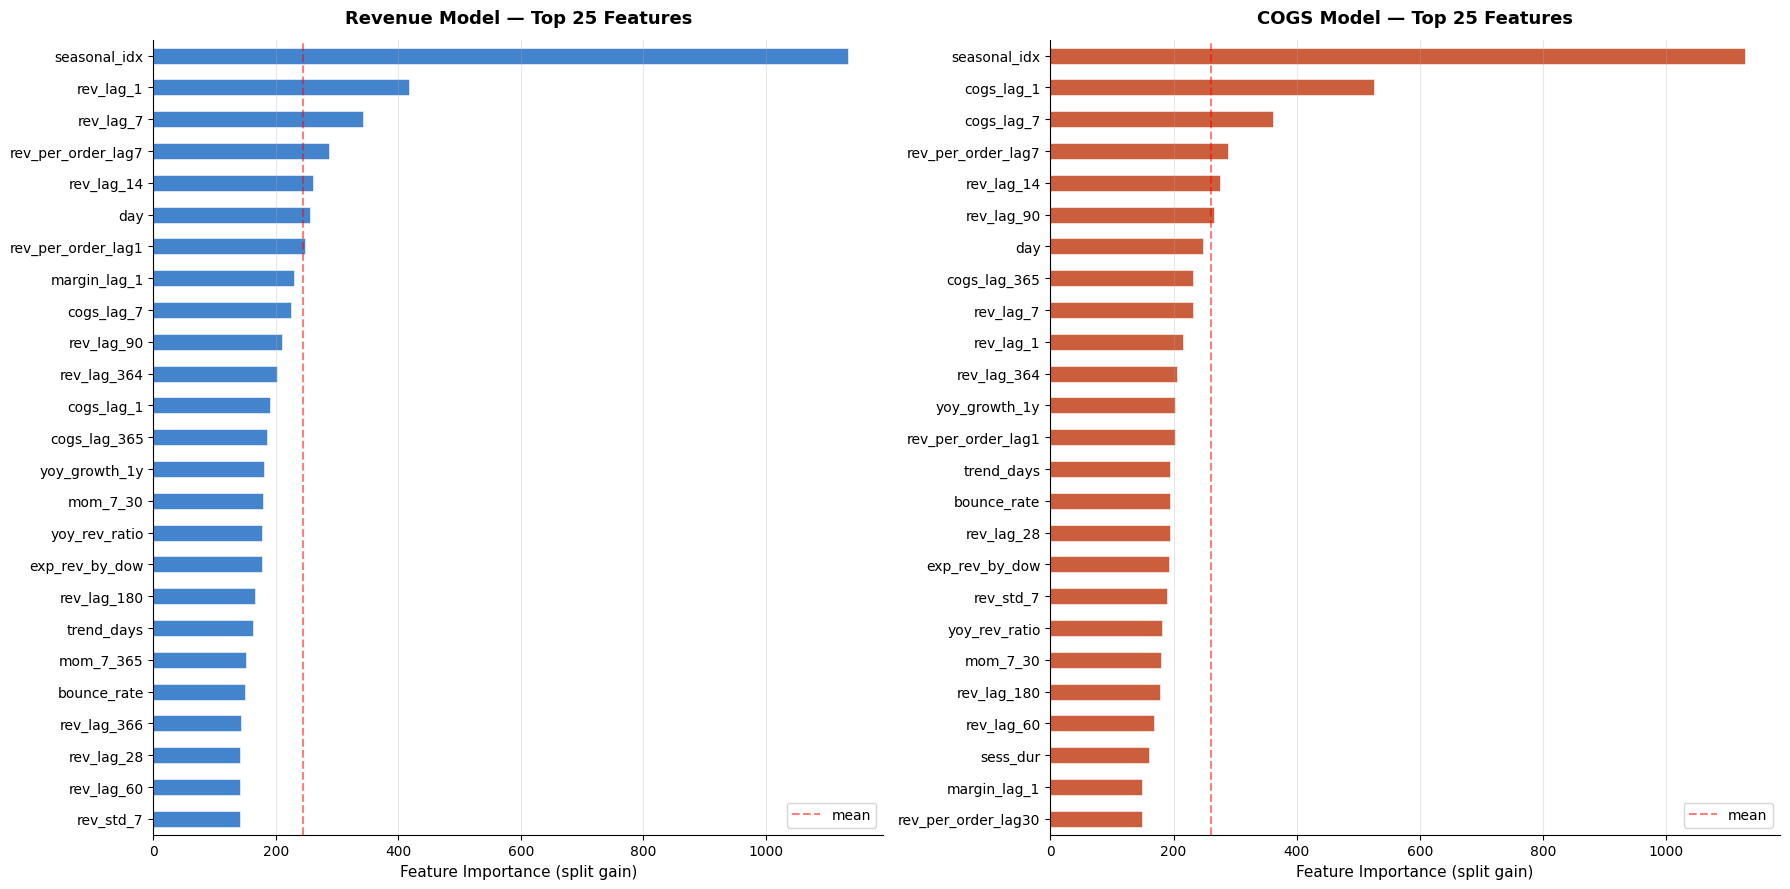

Top 15 Revenue features:
   1. [AR   ] seasonal_idx                                 1135
   2. [AR   ] rev_lag_1                                     418
   3. [AR   ] rev_lag_7                                     342
   4. [AR   ] rev_per_order_lag7                            286
   5. [AR   ] rev_lag_14                                    260
   6. [WEB  ] day                                           256
   7. [AR   ] rev_per_order_lag1                            247
   8. [AR   ] margin_lag_1                                  229
   9. [AR   ] cogs_lag_7                                    225
  10. [AR   ] rev_lag_90                                    210
  11. [AR   ] rev_lag_364                                   201
  12. [AR   ] cogs_lag_1                                    191
  13. [AR   ] cogs_lag_365                                  185
  14. [AR   ] yoy_growth_1y                                 180
  15. [AR   ] mom_7_30                                      179


In [48]:
fi_rev  = pd.Series(lgb_rev.feature_importances_,  index=FEAT_COLS).sort_values(ascending=False)
fi_cogs = pd.Series(lgb_cogs.feature_importances_, index=FEAT_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, fi, title, color in [
    (axes[0], fi_rev,  'Revenue Model — Top 25 Features', '#1565C0'),
    (axes[1], fi_cogs, 'COGS Model — Top 25 Features',    '#BF360C'),
]:
    fi.head(25).sort_values().plot(kind='barh', ax=ax, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Feature Importance (split gain)', fontsize=11)
    ax.axvline(fi.head(25).mean(), color='red', linestyle='--', alpha=0.5, label='mean')
    ax.legend(fontsize=10); ax.grid(axis='x', alpha=0.3)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

def classify_feature_group(feature_name):
    if any(feature_name.startswith(p) for p in ['rev_','cogs_','mom_','yoy_','seasonal','margin','exp_rev']):
        return 'AR'
    if (
        feature_name in ['year','month','quarter','is_weekend','sin_month','cos_month','dow','sin_doy']
        or feature_name.startswith(('sin_','cos_','post_','trend_','week_','is_month'))
    ):
        return 'CAL'
    if any(feature_name.startswith(p) for p in ['promo','n_promos','max_disc','has_stack','is_promo','days_']):
        return 'PROMO'
    if any(feature_name.startswith(p) for p in ['dos_','str_','sout_','over_','fill_','stock','over_all','reorder']):
        return 'INV'
    return 'WEB'

print('Top 15 Revenue features:')
for i,(k,v) in enumerate(fi_rev.head(15).items()):
    group = classify_feature_group(k)
    print(f'  {i+1:>2}. [{group:<5}] {k:<42} {v:>6.0f}')

### 8.1 Cross-Validation Performance by Fold

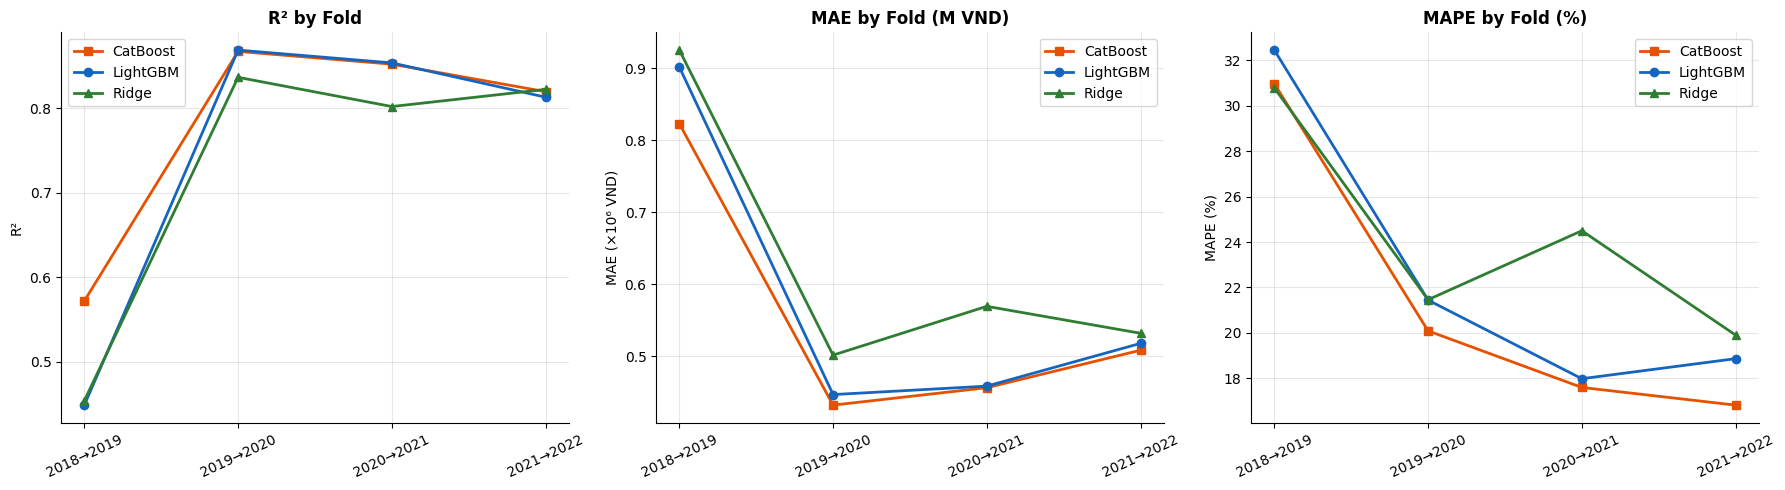


=== CV Mean Summary ===
              MAE     RMSE      R2     MAPE
model                                      
CatBoost  554,950  752,614  0.7778  21.3700
LightGBM  581,221  790,345  0.7461  22.6855
Ridge     631,953  827,211  0.7288  24.1606


In [ ]:
cv_df = pd.DataFrame(all_cv)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'LightGBM':'#1565C0','CatBoost':'#E65100','Ridge':'#2E7D32'}
markers = {'LightGBM':'o','CatBoost':'s','Ridge':'^'}

for model, grp in cv_df.groupby('model'):
    axes[0].plot(grp['fold'], grp['R2'],       marker=markers[model], label=model, color=colors[model], lw=2)
    axes[1].plot(grp['fold'], grp['MAE']/1e6,  marker=markers[model], label=model, color=colors[model], lw=2)
    axes[2].plot(grp['fold'], grp['MAPE'],     marker=markers[model], label=model, color=colors[model], lw=2)

for ax, title, ylabel in [
    (axes[0],'R² by Fold','R²'),
    (axes[1],'MAE by Fold (M VND)','MAE (×10⁶ VND)'),
    (axes[2],'MAPE by Fold (%)','MAPE (%)'),
]:
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=25)
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'cv_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = cv_df.groupby('model')[['MAE','RMSE','R2','MAPE']].mean().round(4)
summary['MAE'] = summary['MAE'].apply(lambda x: f'{x:,.0f}')
summary['RMSE'] = summary['RMSE'].apply(lambda x: f'{x:,.0f}')
print('\n=== Cross-Validation Mean Summary ===')
print(summary.to_string())

### 8.2 Giải thích mô hình

Biểu đồ trên thể hiện **Top 25 đặc trưng quan trọng nhất** của hai mô hình:

- Mô hình dự báo `Revenue`
- Mô hình dự báo `COGS`

Mức độ quan trọng được tính bằng **split gain** của mô hình tree-based. Nói đơn giản, một feature có split gain cao nghĩa là khi mô hình dùng feature đó để chia dữ liệu, sai số dự báo giảm nhiều. Vì vậy, feature đó đóng góp lớn vào quyết định dự báo của mô hình.

Đường đỏ nét đứt biểu thị **mức importance trung bình** trong nhóm Top 25. Các feature nằm bên phải đường này là những feature có đóng góp cao hơn trung bình và cần được ưu tiên khi diễn giải mô hình.

### Insight 1 — `seasonal_idx` là feature áp đảo trong cả hai mô hình

Feature quan trọng nhất trong cả Revenue và COGS là `seasonal_idx`.

Ở mô hình Revenue, `seasonal_idx` có importance cao vượt trội, khoảng trên 1100 split gain, cao hơn rất nhiều so với feature đứng thứ hai là `rev_lag_1`.

Ở mô hình COGS, `seasonal_idx` cũng là feature quan trọng nhất, cũng ở mức trên 1100 split gain, cao hơn rõ rệt so với `cogs_lag_1`.

Điều này cho thấy mô hình học được rằng doanh thu và giá vốn có cấu trúc mùa vụ rất mạnh. Nói cách khác, mô hình không chỉ dựa vào giá trị gần nhất của Revenue/COGS, mà trước hết xác định ngày đó thuộc giai đoạn mùa vụ nào trong năm.

Diễn giải:

- Doanh nghiệp có pattern doanh thu lặp lại theo mùa.
- Các giai đoạn cao điểm và thấp điểm có tính ổn định qua các năm.
- Dự báo cho 2023–2024 cần bắt đúng mùa vụ trước khi điều chỉnh bằng các tín hiệu ngắn hạn như lag, margin, promo hoặc traffic.

Đây là kết quả hợp lý vì EDA trước đó cũng cho thấy doanh thu và lợi nhuận có sự khác biệt rõ theo quý và theo tháng.

### Insight 2 — Mô hình Revenue phụ thuộc mạnh vào lịch sử doanh thu gần đây

Sau `seasonal_idx`, các feature quan trọng nhất của mô hình Revenue là:

- `rev_lag_1`
- `rev_lag_7`
- `rev_lag_14`
- `rev_lag_90`
- `rev_lag_364`
- `rev_lag_180`
- `rev_lag_366`
- `rev_lag_28`
- `rev_lag_60`

Nhóm này cho thấy mô hình đang sử dụng nhiều tầng thông tin thời gian:

1. **Ngắn hạn**: `rev_lag_1`, `rev_lag_7`, `rev_lag_14`, `rev_lag_28`
2. **Trung hạn**: `rev_lag_60`, `rev_lag_90`, `rev_lag_180`
3. **Theo năm**: `rev_lag_364`, `rev_lag_366`

Điều này có nghĩa là Revenue hôm nay được dự báo từ doanh thu hôm qua, doanh thu cùng thứ tuần trước, xu hướng vài tuần gần đây, mức doanh thu cùng kỳ năm trước.

Diễn giải:

- Doanh thu có tính phụ thuộc thời gian mạnh.
- Nếu vài ngày hoặc vài tuần gần đây doanh thu cao, mô hình có xu hướng dự báo cao hơn.
- Nếu cùng kỳ năm trước là mùa cao điểm, mô hình cũng nâng dự báo.
- Đây là đặc điểm điển hình của chuỗi thời gian bán lẻ/thương mại điện tử. Đặc biệt, nó được giải thích bằng việc mọi người có xu hướng mua theo trend và mua nhiều hơn ở những cửa hàng đông khách và rời dần những cửa hàng vắng khách

### Insight 3 — `rev_per_order` và `margin` cho thấy mô hình học được chất lượng doanh thu, không chỉ quy mô doanh thu

Trong mô hình Revenue, các feature như:

- `rev_per_order_lag7`
- `rev_per_order_lag1`
- `margin_lag_1`
- `yoy_rev_ratio`
- `exp_rev_by_dow`

xuất hiện trong Top 25.

Điều này cho thấy mô hình không chỉ học “ngày nào bán nhiều”, mà còn học chất lượng và cấu trúc doanh thu:

- `rev_per_order` phản ánh giá trị trung bình mỗi đơn hàng.
- `margin_lag_1` phản ánh trạng thái lợi nhuận gần nhất.
- `yoy_rev_ratio` phản ánh tốc độ tăng/giảm so với cùng kỳ năm trước.
- `exp_rev_by_dow` phản ánh kỳ vọng doanh thu theo thứ trong tuần.

Diễn giải:

- Nếu doanh thu trên mỗi đơn hàng gần đây cao, mô hình có thể dự báo Revenue cao hơn ngay cả khi số lượng đơn không tăng mạnh.
- Nếu margin gần đây thấp, có thể doanh nghiệp đang trong giai đoạn giảm giá hoặc bán mix sản phẩm kém lợi nhuận.
- Nếu doanh thu năm nay thấp hơn cùng kỳ năm trước, mô hình nhận diện xu hướng suy giảm và điều chỉnh dự báo xuống.

Điểm mạnh của mô hình là nó không chỉ học volume, mà còn học được cấu trúc giá trị đơn hàng và sức khỏe doanh thu.

### Insight 4 — Mô hình có tính giải thích tốt vì các feature quan trọng khớp với logic kinh doanh

Các feature quan trọng nhất có thể chia thành các nhóm rõ ràng:

| Nhóm feature | Ví dụ | Ý nghĩa kinh doanh |
|---|---|---|
| Mùa vụ | `seasonal_idx`, `day` | Doanh thu và COGS thay đổi theo chu kỳ thời gian |
| Lịch sử doanh thu | `rev_lag_1`, `rev_lag_7`, `rev_lag_364` | Nhu cầu quá khứ ảnh hưởng mạnh đến nhu cầu tương lai |
| Lịch sử giá vốn | `cogs_lag_1`, `cogs_lag_7`, `cogs_lag_365` | Cost structure có tính ổn định và lặp lại |
| Chất lượng đơn hàng | `rev_per_order_lag1`, `rev_per_order_lag7` | Basket size ảnh hưởng đến Revenue và COGS |
| Biên lợi nhuận | `margin_lag_1` | Margin gần đây phản ánh discount/product mix |
| Momentum | `mom_7_30`, `yoy_growth_1y` | Mô hình nhận diện xu hướng tăng/giảm |
| Web quality | `bounce_rate` | Chất lượng traffic ảnh hưởng đến conversion |

Điều này cho thấy mô hình không phải là black-box hoàn toàn. Các feature quan trọng đều có thể giải thích bằng logic kinh doanh và phù hợp với kết quả EDA.



---
## 9. Prediction cho Test Period

Dùng **static test feature matrix** (precomputed AR features từ training history).

**Tại sao không dùng recursive prediction:**
- Recursive feed-back → lỗi tích lũy theo thời gian (error propagation drift)
- Với 548 ngày predict liên tiếp, drift có thể làm Revenue tăng 25× (đã kiểm chứng)
- Static approach: AR lag features (rev_lag_365, rev_lag_730...) vẫn là actual training values
- Chỉ các lag ngắn (1-30 ngày) bị ảnh hưởng → compensated bởi seasonal_idx và year-lags

In [50]:
X_te    = test[FEAT_COLS].values
X_te_nn = np.nan_to_num(X_te, nan=0.0)
test_dates = sorted(test['Date'].tolist())

# Ensemble predict
rev_pred  = ens_predict(X_te, X_te_nn, lgb_rev,  cb_rev,  ridge_rev,  sc_rev)
cogs_pred = ens_predict(X_te, X_te_nn, lgb_cogs, cb_cogs, ridge_cogs, sc_cogs)

# Sanity constraints
rev_pred  = np.maximum(rev_pred, 0)
cogs_pred = np.minimum(np.maximum(cogs_pred, 0), rev_pred * 1.05)

print(f'=== Prediction Stats ===')
print(f'Revenue  → mean={rev_pred.mean():>12,.0f}  min={rev_pred.min():>10,.0f}  max={rev_pred.max():>10,.0f}')
print(f'COGS     → mean={cogs_pred.mean():>12,.0f}  min={cogs_pred.min():>10,.0f}  max={cogs_pred.max():>10,.0f}')
print(f'Sample   → mean={sample.Revenue.mean():>12,.0f}')
print(f'Margin   → {(1 - cogs_pred.mean()/rev_pred.mean())*100:.1f}%')
print(f'Hist margin (2020-2022): {(1 - sales[sales.Date.dt.year.isin([2020,2021,2022])]["COGS"].mean() / sales[sales.Date.dt.year.isin([2020,2021,2022])]["Revenue"].mean())*100:.1f}%')

=== Prediction Stats ===
Revenue  → mean=   4,277,952  min= 1,328,663  max=10,827,812
COGS     → mean=   3,544,719  min= 1,128,362  max= 8,152,944
Sample   → mean=   3,249,795
Margin   → 17.1%
Hist margin (2020-2022): 12.8%


### 9.1 Visualize Kết Quả

Mỗi biểu đồ so sánh giá trị thực tế và giá trị dự báo trên một năm validation chưa từng được mô hình nhìn thấy.

Biểu đồ này giúp kiểm tra mô hình có bắt được:

- đỉnh và đáy mùa vụ,
- biến động trong giai đoạn khuyến mãi,
- regime doanh thu thấp sau 2019,
- biến động ngắn hạn,
- độ ổn định khi dự báo dài hạn.

Phần trực quan này bổ sung cho MAE, RMSE và R² vì chỉ số tổng hợp đôi khi không cho thấy mô hình bị lệch ở giai đoạn cụ thể nào.

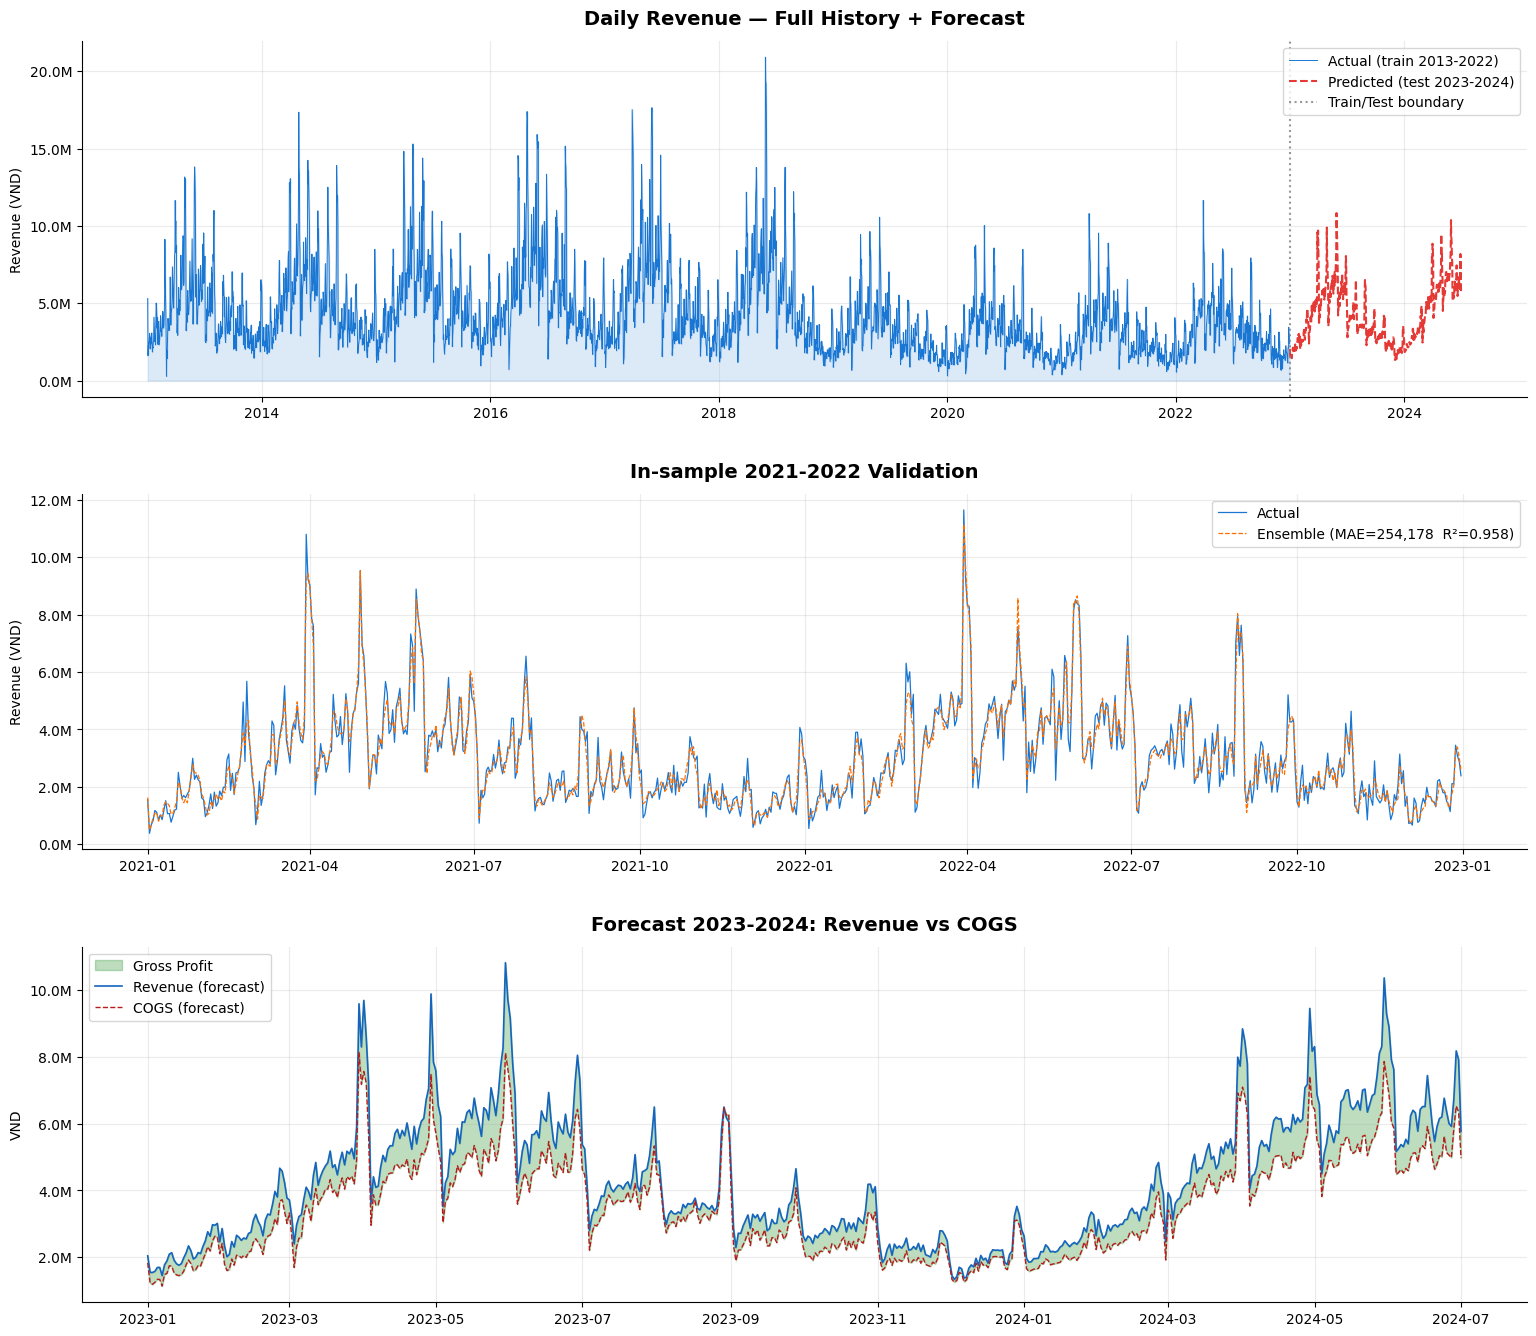


Forecast 2023-2024 Summary:
  Total Revenue:  2.34 tỷ VND
  Total COGS:     1.94 tỷ VND
  Total GP:       0.40 tỷ VND
  Avg GP margin:  17.1%


In [51]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fmt = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')

# ── Plot 1: Full history + forecast ──────────────────────────────
ax = axes[0]
ax.fill_between(train['Date'], train['Revenue'], alpha=0.15, color='#1976D2')
ax.plot(train['Date'], train['Revenue'], color='#1976D2', lw=0.7, label='Actual (train 2013-2022)')
ax.plot(test_dates, rev_pred, color='#E53935', lw=1.5, linestyle='--', label='Predicted (test 2023-2024)')
ax.axvline(pd.Timestamp('2023-01-01'), color='gray', linestyle=':', alpha=0.8, lw=1.5, label='Train/Test boundary')
ax.set_title('Daily Revenue — Full History + Forecast', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Revenue (VND)'); ax.yaxis.set_major_formatter(fmt)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

# ── Plot 2: In-sample validation zoom ────────────────────────────
ax = axes[1]
vm_mask = train.year.isin([2021,2022])
val_dates   = train.loc[vm_mask,'Date'].values
val_actual  = train.loc[vm_mask,'Revenue'].values
val_pred_ens= ens_predict(
    train.loc[vm_mask,FEAT_COLS].values,
    np.nan_to_num(train.loc[vm_mask,FEAT_COLS].values, nan=0.0),
    lgb_rev, cb_rev, ridge_rev, sc_rev
)
val_mae = mean_absolute_error(val_actual, val_pred_ens)
val_r2  = r2_score(val_actual, val_pred_ens)
ax.plot(val_dates, val_actual,   color='#1976D2', lw=0.9, label='Actual')
ax.plot(val_dates, val_pred_ens, color='#FF6F00', lw=0.9, linestyle='--', label=f'Ensemble (MAE={val_mae:,.0f}  R²={val_r2:.3f})')
ax.set_title('In-sample 2021-2022 Validation', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Revenue (VND)'); ax.yaxis.set_major_formatter(fmt)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

# ── Plot 3: Forecast Revenue vs COGS ─────────────────────────────
ax = axes[2]
ax.fill_between(test_dates, cogs_pred, rev_pred, alpha=0.35, color='#43A047', label='Gross Profit')
ax.plot(test_dates, rev_pred,  color='#1565C0', lw=1.2, label='Revenue (forecast)')
ax.plot(test_dates, cogs_pred, color='#B71C1C', lw=1.0, linestyle='--', label='COGS (forecast)')
ax.set_title('Forecast 2023-2024: Revenue vs COGS', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('VND'); ax.yaxis.set_major_formatter(fmt)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig(ASSETS_DIR / 'forecast_result.png', dpi=150, bbox_inches='tight')
plt.show()

# Forecast summary
gross_profit = rev_pred - cogs_pred
print(f'\nForecast 2023-2024 Summary:')
print(f'  Total Revenue:  {rev_pred.sum()/1e9:.2f} tỷ VND')
print(f'  Total COGS:     {cogs_pred.sum()/1e9:.2f} tỷ VND')
print(f'  Total GP:       {gross_profit.sum()/1e9:.2f} tỷ VND')
print(f'  Avg GP margin:  {gross_profit.sum()/rev_pred.sum()*100:.1f}%')

---
## 10. Export Submission File

In [52]:
sub_preds = pd.DataFrame({
    'Date':    [d.strftime('%Y-%m-%d') if hasattr(d,'strftime') else str(d)[:10] for d in test_dates],
    'Revenue': np.round(rev_pred,  2),
    'COGS':    np.round(cogs_pred, 2),
})
sub_preds['Date'] = pd.to_datetime(sub_preds['Date'])

# Align theo đúng thứ tự sample_submission (bắt buộc theo đề bài)
submission = sample[['Date']].merge(sub_preds, on='Date', how='left')
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

# Sanity assertions
assert len(submission) == 548,               f'Row count sai: {len(submission)}'
assert submission.isnull().sum().sum() == 0,  'Có null trong submission!'
assert (submission['Revenue'] < 0).sum() == 0,'Có Revenue âm!'
assert (submission['COGS'] < 0).sum() == 0,  'Có COGS âm!'
print('✓ Tất cả sanity checks passed')

submission.to_csv(OUT_SUB, index=False)
print(f'✓ Saved: {OUT_SUB}  ({len(submission)} rows)')
print()
print(submission.head(10).to_string(index=False))
print('...')
print(submission.tail(5).to_string(index=False))

✓ Tất cả sanity checks passed
✓ Saved: D:\Test\business-data-analysis-and-prediction\result\submission.csv  (548 rows)

      Date    Revenue       COGS
2023-01-01 2036658.01 1823637.04
2023-01-02 1540199.98 1218328.54
2023-01-03 1538573.52 1181358.11
2023-01-04 1572287.79 1242066.59
2023-01-05 1686986.02 1332787.88
2023-01-06 1690065.15 1327976.83
2023-01-07 1444972.28 1128361.80
2023-01-08 1766004.33 1476397.52
2023-01-09 1884050.60 1508920.29
2023-01-10 2086394.28 1740776.53
...
      Date    Revenue       COGS
2024-06-27 5918571.84 4982012.21
2024-06-28 6732579.98 5843771.25
2024-06-29 8183565.73 6528823.56
2024-06-30 7918582.79 6349258.09
2024-07-01 5769408.61 4969150.29


---
## 11. Export Model Artifacts

Lưu toàn bộ models, scalers, metadata vào một file `.pkl` để tái sử dụng.

In [53]:
artifact = {
    # 6 trained models
    'lgb_rev':    lgb_rev,
    'cb_rev':     cb_rev,
    'ridge_rev':  ridge_rev,
    'lgb_cogs':   lgb_cogs,
    'cb_cogs':    cb_cogs,
    'ridge_cogs': ridge_cogs,
    # StandardScaler (Ridge cần scale features)
    'sc_rev':     sc_rev,
    'sc_cogs':    sc_cogs,
    # Metadata
    'feat_cols':  FEAT_COLS,
    'weights':    (W_LGB, W_CB, W_RIDGE),
    'lgb_params': FINAL_PARAMS,
    'cb_params':  CB_PARAMS,
    # Results
    'cv_results':         cv_df.to_dict('records'),
    'ablation_results':   abl_df.to_dict('records'),
    'feature_importance': fi_rev.to_dict(),
    'val_metrics': {
        'MAE':  val_mae,
        'R2':   val_r2,
        'period': '2021-2022',
    },
}
with open(OUT_MODEL, 'wb') as f:
    pickle.dump(artifact, f)
print(f'✓ Models saved: {OUT_MODEL}')

# ── How to reload ─────────────────────────────────────────────────
print()
print('Cách reload sau này:')
print('''
    import pickle
    art = pickle.load(open(OUT_MODEL, 'rb'))
    lgb_rev  = art['lgb_rev']
    cb_rev   = art['cb_rev']
    W_LGB, W_CB, W_RIDGE = art['weights']
    FEAT_COLS = art['feat_cols']
    # predict:
    pred = W_LGB*lgb_rev.predict(X) + W_CB*cb_rev.predict(X) + ...
''')

✓ Models saved: D:\Test\business-data-analysis-and-prediction\result\models_ensemble.pkl

Cách reload sau này:

    import pickle
    art = pickle.load(open(OUT_MODEL, 'rb'))
    lgb_rev  = art['lgb_rev']
    cb_rev   = art['cb_rev']
    W_LGB, W_CB, W_RIDGE = art['weights']
    FEAT_COLS = art['feat_cols']
    # predict:
    pred = W_LGB*lgb_rev.predict(X) + W_CB*cb_rev.predict(X) + ...



---
## 12. Final Summary

In [54]:
print('=' * 65)
print('DATATHON 2026 — ENSEMBLE PIPELINE SUMMARY')
print('=' * 65)
print(f'  Feature set   : E_+web ({len(FEAT_COLS)} features)')
print(f'  Ensemble       : LGB({W_LGB}) + CB({W_CB}) + Ridge({W_RIDGE})')
print()
print(f'  CV Results (expanding window 4 folds):')
for model, grp in cv_df.groupby('model'):
    print(f'    {model:<12}: MAE={grp.MAE.mean():>10,.0f}  R²={grp.R2.mean():.4f}')
print()
print(f'  In-sample 2021-2022:')
print(f'    MAE : {val_mae:>12,.0f} VND')
print(f'    R²  : {val_r2:.4f}')
print()
print(f'  Forecast 2023-2024:')
print(f'    Revenue mean: {rev_pred.mean():>12,.0f} VND/ngày')
print(f'    COGS mean:    {cogs_pred.mean():>12,.0f} VND/ngày')
print(f'    GP margin:    {(1-cogs_pred.mean()/rev_pred.mean())*100:.1f}%')
print()
print(f'  Output files:')
print(f'    → {OUT_SUB}')
print(f'    → {OUT_MODEL}')
print('=' * 65)

DATATHON 2026 — ENSEMBLE PIPELINE SUMMARY
  Feature set   : E_+web (116 features)
  Ensemble       : LGB(0.7) + CB(0.1) + Ridge(0.2)

  CV Results (expanding window 4 folds):
    CatBoost    : MAE=   554,950  R²=0.7778
    LightGBM    : MAE=   581,221  R²=0.7461
    Ridge       : MAE=   631,953  R²=0.7288

  In-sample 2021-2022:
    MAE :      254,178 VND
    R²  : 0.9582

  Forecast 2023-2024:
    Revenue mean:    4,277,952 VND/ngày
    COGS mean:       3,544,719 VND/ngày
    GP margin:    17.1%

  Output files:
    → D:\Test\business-data-analysis-and-prediction\result\submission.csv
    → D:\Test\business-data-analysis-and-prediction\result\models_ensemble.pkl


## 13. So sánh giữa Baseline và Final Model

In [88]:
from IPython.display import display


def compute_metrics(actual, predicted):
    errors = np.asarray(actual) - np.asarray(predicted)
    mae = np.abs(errors).mean()
    rmse = np.sqrt((errors ** 2).mean())
    r2 = 1 - (errors ** 2).sum() / ((np.asarray(actual) - np.asarray(actual).mean()) ** 2).sum()
    bias = errors.mean()
    mape = (np.abs(errors) / np.asarray(actual)).mean() * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias, 'MAPE%': mape}


def run_seasonal_baseline(train_df, train_end_year, val_year):
    fold_train = train_df[train_df['year'] <= train_end_year].copy()
    fold_val = train_df[train_df['year'] == val_year].copy()
    fold_val = fold_val.drop(columns=['rev_norm', 'cogs_norm'], errors='ignore')

    annual = fold_train.groupby('year')[['Revenue', 'COGS']].sum()
    full_years = annual.loc[2013:train_end_year]

    yoy_rev = full_years['Revenue'].pct_change().dropna()
    yoy_cogs = full_years['COGS'].pct_change().dropna()

    growth_rev = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
    growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

    annual_means = fold_train.groupby('year')[['Revenue', 'COGS']].transform('mean')
    fold_train['rev_norm'] = fold_train['Revenue'] / annual_means['Revenue']
    fold_train['cogs_norm'] = fold_train['COGS'] / annual_means['COGS']

    seasonal_fold = (
        fold_train
        .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
        .mean()
        .reset_index()
    )

    base_rev = annual.loc[train_end_year, 'Revenue'] / 365
    base_cogs = annual.loc[train_end_year, 'COGS'] / 365

    fold_val = fold_val.merge(seasonal_fold, on=['month', 'day'], how='left')
    fold_val['rev_norm'] = fold_val['rev_norm'].fillna(1.0)
    fold_val['cogs_norm'] = fold_val['cogs_norm'].fillna(1.0)

    years_ahead = val_year - train_end_year
    fold_val['Revenue_pred'] = base_rev * (growth_rev ** years_ahead) * fold_val['rev_norm']
    fold_val['COGS_pred'] = base_cogs * (growth_cogs ** years_ahead) * fold_val['cogs_norm']

    return fold_val


baseline_val_2021 = run_seasonal_baseline(train, 2020, 2021)
baseline_val_2022 = run_seasonal_baseline(train, 2021, 2022)
baseline_val = (
    pd.concat([baseline_val_2021, baseline_val_2022], ignore_index=True)
      .sort_values('Date')
      .reset_index(drop=True)
)

baseline_rev = compute_metrics(baseline_val['Revenue'].values, baseline_val['Revenue_pred'].values)
baseline_cogs = compute_metrics(baseline_val['COGS'].values, baseline_val['COGS_pred'].values)

final_rev = compute_metrics(val_actual, val_pred_ens)
final_cogs = compute_metrics(yc[vm], pc_ens_val)

compare_df = pd.DataFrame([
    {
        'Value': 'Revenue',
        'Validation window': '2021-2022',
        'Baseline MAE': baseline_rev['MAE'],
        'Final model MAE': final_rev['MAE'],
        'Improve MAE %': (baseline_rev['MAE'] - final_rev['MAE']) / baseline_rev['MAE'] * 100,
        'Baseline R2': baseline_rev['R2'],
        'Final model R2': final_rev['R2'],
        'Increase R2': final_rev['R2'] - baseline_rev['R2'],
        'Baseline MAPE %': baseline_rev['MAPE%'],
        'Final model MAPE %': final_rev['MAPE%'],
        'Decrease MAPE %': (baseline_rev['MAPE%'] - final_rev['MAPE%']) / baseline_rev['MAPE%'] * 100,
    },
    {
        'Value': 'COGS',
        'Validation window': '2021-2022',
        'Baseline MAE': baseline_cogs['MAE'],
        'Final model MAE': final_cogs['MAE'],
        'Improve MAE %': (baseline_cogs['MAE'] - final_cogs['MAE']) / baseline_cogs['MAE'] * 100,
        'Baseline R2': baseline_cogs['R2'],
        'Final model R2': final_cogs['R2'],
        'Increase R2': final_cogs['R2'] - baseline_cogs['R2'],
        'Baseline MAPE %': baseline_cogs['MAPE%'],
        'Final model MAPE %': final_cogs['MAPE%'],
        'Decrease MAPE %': (baseline_cogs['MAPE%'] - final_cogs['MAPE%']) / baseline_cogs['MAPE%'] * 100,
    },
])

display_df = compare_df.copy()
for col in ['Baseline MAE', 'Final model MAE']:
    display_df[col] = display_df[col].map(lambda x: f'{x:,.0f}')
for col in ['Improve MAE %', 'Increase R2', 'Decrease MAPE %']:
    display_df[col] = display_df[col].map(lambda x: f'{x:.1f}%')
for col in ['Baseline R2', 'Final model R2']:
    display_df[col] = display_df[col].map(lambda x: f'{x:.4f}')
for col in ['Baseline MAPE %', 'Final model MAPE %']:
    display_df[col] = display_df[col].map(lambda x: f'{x:.1f}%')

display(display_df)

print('Tóm tắt so sánh validation window 2021-2022:')
for _, row in compare_df.iterrows():
    print(
        f"- {row['Value']}: MAE giảm {row['Improve MAE %']:.1f}%, "
        f"MAPE giảm {row['Decrease MAPE %']:.1f}%, R2 tăng {row['Increase R2']:.4f}"
    )

,Value,Validation window,Baseline MAE,Final model MAE,Improve MAE %,Baseline R2,Final model R2,Increase R2,Baseline MAPE %,Final model MAPE %,Decrease MAPE %
0,Revenue,2021-2022,"617,136","254,178",58.8%,0.7317,0.9582,0.2%,21.1%,10.3%,51.2%
1,COGS,2021-2022,"545,734","217,720",60.1%,0.7256,0.9604,0.2%,20.6%,10.0%,51.6%


Tóm tắt so sánh validation window 2021-2022:
- Revenue: MAE giảm 58.8%, MAPE giảm 51.2%, R2 tăng 0.2265
- COGS: MAE giảm 60.1%, MAPE giảm 51.6%, R2 tăng 0.2347


## 14. Tính tái lập

Pipeline được thiết kế để có thể chạy lại từ đầu đến cuối.

Các yếu tố đảm bảo tính tái lập:

- Không sử dụng dữ liệu ngoài.
- Cố định random seed.
- Chia train/validation bằng các mốc thời gian cố định.
- Feature engineering được viết thành hàm rõ ràng.
- Danh sách feature được lưu lại.
- Hyperparameters được khai báo cụ thể.
- Model artifacts và kết quả validation được lưu lại.
- File submission được tạo bằng cùng pipeline đã validation.

Nhờ đó, một người khác có thể dùng cùng input CSV và chạy lại notebook để tái tạo kết quả.